# 04. Optimization Techniques

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement gradient-based optimization and variants
- Tune learning rates and compare optimizers

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — the same recipe (define a loss, then follow the slope downhill), here with slopes measured numerically and several optimizers compared.

**Used later in:** Course 03 (AIAT 113) — Unit 2, which computes those slopes exactly with calculus, and Unit 3, which compares SGD, Adam and friends; Course 08 (AIAT 122) — Unit 1 applies them to deep networks.

---


# 04. Optimization Techniques

---

## The Story: Finding the Best Solution

**THE PROBLEM**: We need to find the minimum/maximum of a function, but we don't know where it is!

**BEFORE**: We might try random values or guess - inefficient and might miss the best solution.
**AFTER**: We use optimization algorithms (gradient descent, genetic algorithms) to systematically find the best solution!

---

## ❌ THE PROBLEM: Why Optimization Matters

**Problem 1**: We need to minimize cost, maximize profit, or find optimal parameters
- Machine learning: Find best model parameters
- Engineering: Minimize material cost while maintaining strength
- Business: Maximize profit with limited resources

**Problem 2**: Without optimization algorithms, we:
- Try random values (inefficient, might never find optimum)
- Check every possible value (too slow for large problems)
- Guess based on experience (might miss better solutions)

**WHY IT MATTERS**: Finding the optimal solution can save money, improve performance, or enable new capabilities!

---

## ✅ THE SOLUTION: Optimization Algorithms

**Solution**: Use mathematical optimization algorithms:
1. **Gradient Descent**: Follow the slope downhill to find minimum
2. **Genetic Algorithms**: Evolve solutions like natural selection
3. **Simulated Annealing**: Escape local minima to find global optimum

**HOW IT SOLVES IT**:
- ✅ Instead of random search → Systematic search
- ✅ Instead of checking everything → Smart algorithms that find optimum faster
- ✅ Instead of guessing → Mathematical methods that efficiently find optimum

## Learning Objectives
1. Understand the PROBLEM of optimization
2. Learn the SOLUTION: optimization algorithms
3. See HOW they solve real-world problems
4. Compare BEFORE (random/guess) vs AFTER (systematic optimization)


## 🌍 The case: an antenna nobody designed, and a national railway timetable

**IBM, 1983.** Kirkpatrick, Gelatt and Vecchi published *Optimization by Simulated Annealing* in **Science 220, 671–680** — reference 1 at the end of this notebook. Their motivating problem was not a toy curve: it was **placing and wiring components on VLSI chips**, a combinatorial layout problem with no gradient anywhere in it, where a greedy arrangement locks into a bad configuration almost immediately. Their move was to borrow the Metropolis algorithm from statistical physics and treat *cooling* as a search schedule. You will implement the same schedule in Part 4.

**NASA, launched 22 March 2006.** The X-band antenna flown on the three **Space Technology 5** spacecraft was not designed by an engineer. It was **evolved** — Hornby, Lohn and Linden at NASA Ames ran evolutionary algorithms over antenna shapes, and the evolved designs **outperformed the hand-built antenna the mission's own contractor had produced**. When the spacecraft's orbit changed late in the programme, the team adjusted the fitness function and evolved a replacement set in under a month. It was the first computer-evolved hardware to fly in space, and it looks like a bent paperclip, because nothing constrained it to look like an antenna.

**Netherlands Railways, timetable of December 2006 — INFORMS Franz Edelman Award, 2008.** An entire national railway timetable for about 5,500 daily trains, produced by mathematical optimization rather than by hand — constraint programming for the timetable itself, integer programming for station routing and rolling stock, column generation for crew. Reported outcomes (Kroon *et al.*, *Interfaces* 39(1), 2009): trains arriving within 3 minutes of schedule rose from **84.8% in 2006 to 87.0% in 2007**, passengers grew 2.8% on average across 2007 with about two percentage points of the long-run increase attributed to the new timetable, and the new schedules were credited with about **€40 million** in additional annual profit, expected to grow to €70 million. Note which methods actually shipped: this is combinatorial optimization at national scale, and simulated annealing — the method you build in Part 4 — is one tool in that family, not the one Netherlands Railways used.

### What goes wrong without this

The failure of hand-tuning is not that it finds a bad answer. It is that it finds a *workable* answer and then gives you **no way to know how much better the best answer is**. You stop, you ship, and the gap is invisible forever.

This notebook makes that gap measurable. In Part 4, gradient descent starting from x = 5.0 on f(x) = (x−2)² + 2·sin(5x) reports `✅ Converged after 22 iterations` and settles at f = **5.0674**. Simulated annealing, from the same start on the same function, reaches f = **−1.9610**. Same problem, same starting point, a difference of 7 units — and the gradient-descent run announced success.

---


## Part 1: ❌ BEFORE - The Problem

**THE PROBLEM**: Finding the minimum of a function without optimization.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/crime_statistics_original_50.csv' only
#       resolves when the kernel's working directory happens to be this notebook's folder.
#       This does not care where you opened the notebook from.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("crime_statistics_original_50"), ...
# -------------------------------------------------------------------- 8< ----------------
print("Data loader ready. Datasets are found automatically - no file paths in this notebook.")


Data loader ready. Datasets are found automatically - no file paths in this notebook.


❌ BEFORE: The Problem - Finding Minimum Without Optimization

Problem: Find x that minimizes f(x) = x²

❌ PROBLEM 1: Random Search (Inefficient)
   • Try random values: x = 5, x = -3, x = 2.7, x = -1.2...
   • Check each one: f(5) = 25, f(-3) = 9, f(2.7) = 7.29...
   • Keep trying until we find something close
   → Very slow! Might take thousands of tries!

❌ PROBLEM 2: Grid Search (Too Slow)
   • Check every value: x = -10, -9.99, -9.98, ..., 9.99, 10
   • Check 20,000 values to get 0.001 precision
   → Too slow for high-dimensional problems!

❌ PROBLEM 3: Guessing (Might Miss Optimum)
   • Guess: 'I think x = 0 looks good'
   • But what if we have a more complex function?
   → Might miss the actual minimum!

🤔 WHY THIS IS A PROBLEM:
   • ML training: Need optimal parameters for accuracy
   • Engineering: Optimal design saves money
   • Business: Optimal decisions maximize profit

💡 THE SOLUTION: Use optimization algorithms!


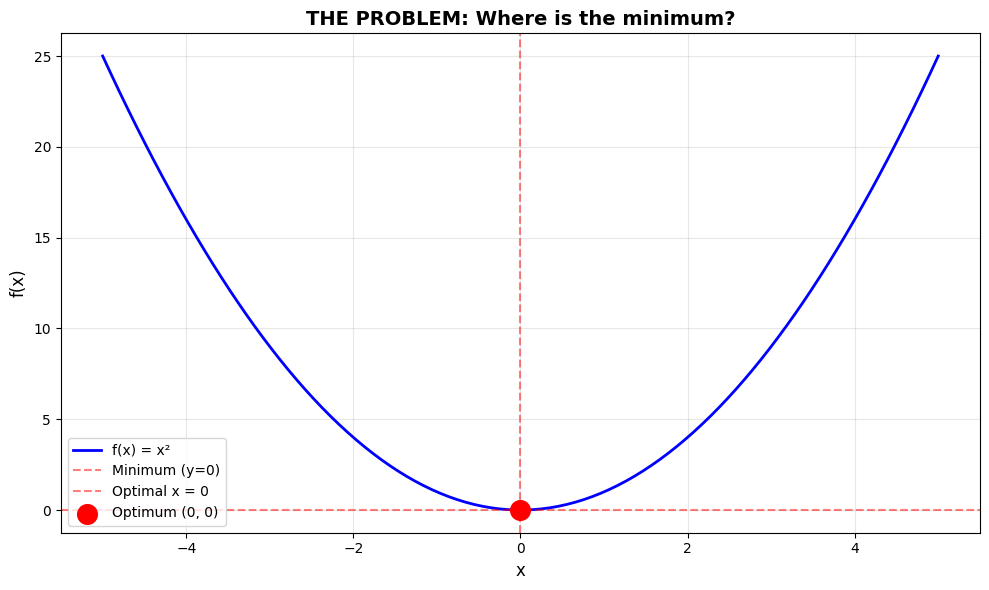

📊 Visual: The problem - where is the minimum? (Without optimization, hard to find!)


In [2]:
# Set up the running example: define f(x) = x^2 and plot it, so 'find the minimum' becomes a concrete picture.
import numpy as np
import matplotlib.pyplot as plt

# ❌ THE PROBLEM: We need to find the minimum of f(x) = x²
# Without optimization, how do we find it?

def f(x):
    """Function we want to minimize: f(x) = x²
    
    Handles both scalar and array inputs for flexibility.
    """
    # Convert to array if needed, then handle appropriately
    x_arr = np.asarray(x)
    if x_arr.ndim == 0:  # Scalar
        return float(x_arr)**2
    else:  # Array
        return x_arr**2  # Square all elements (corrected from x_arr[0]**2)

print("=" * 70)
print("❌ BEFORE: The Problem - Finding Minimum Without Optimization")
print("=" * 70)
print()
print("Problem: Find x that minimizes f(x) = x²")
print()
print("❌ PROBLEM 1: Random Search (Inefficient)")
print("   • Try random values: x = 5, x = -3, x = 2.7, x = -1.2...")
print("   • Check each one: f(5) = 25, f(-3) = 9, f(2.7) = 7.29...")
print("   • Keep trying until we find something close")
print("   → Very slow! Might take thousands of tries!")
print()
print("❌ PROBLEM 2: Grid Search (Too Slow)")
print("   • Check every value: x = -10, -9.99, -9.98, ..., 9.99, 10")
print("   • Check 20,000 values to get 0.001 precision")
print("   → Too slow for high-dimensional problems!")
print()
print("❌ PROBLEM 3: Guessing (Might Miss Optimum)")
print("   • Guess: 'I think x = 0 looks good'")
print("   • But what if we have a more complex function?")
print("   → Might miss the actual minimum!")
print()
print("🤔 WHY THIS IS A PROBLEM:")
print("   • ML training: Need optimal parameters for accuracy")
print("   • Engineering: Optimal design saves money")
print("   • Business: Optimal decisions maximize profit")
print()
print("💡 THE SOLUTION: Use optimization algorithms!")

# Visualize the problem
x_vals = np.linspace(-5, 5, 100)
y_vals = x_vals**2

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = x²')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Minimum (y=0)')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='Optimal x = 0')
plt.scatter([0], [0], color='red', s=200, zorder=5, label='Optimum (0, 0)')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('THE PROBLEM: Where is the minimum?', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("📊 Visual: The problem - where is the minimum? (Without optimization, hard to find!)")

## Part 2: ✅ AFTER - The Solution: Gradient Descent

**THE SOLUTION**: Use gradient descent to systematically find the minimum!

**No calculus needed (yet!)** — the "gradient" is just the *slope* of the function: which way is uphill, and how steeply. We **measure** it numerically by nudging `x` a tiny amount and watching how much `f(x)` changes:

$$\text{slope} \approx \frac{f(x+h) - f(x-h)}{2h} \quad \text{for a tiny } h$$

Computing this slope *exactly* (instead of measuring it) is what derivatives do — and that is taught in the next course, **Course 03 (AIAT 113)**, `unit2-calculus`. Here, "measure the slope, step downhill, repeat" is the whole algorithm.


In [3]:
# THE SOLUTION, part 1: gradient descent - measure the slope, step downhill, repeat.
import numpy as np
# ✅ THE SOLUTION: Gradient Descent
# This algorithm solves the problem by following the gradient (slope) downhill

class GradientDescent:
    """
    Gradient Descent: The SOLUTION to the optimization problem.
    
    THE PROBLEM: We don't know where the minimum is.
    THE SOLUTION: Follow the gradient (slope) downhill - it always leads to minimum!
    
    How it works:
    1. Start at random point
    2. Calculate gradient (which way is downhill?)
    3. Move in that direction (downhill)
    4. Repeat until we reach the bottom (minimum)
    """
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        """
        Initialize optimizer.
        - learning_rate: How big steps to take (too big = overshoot, too small = slow)
        - max_iterations: Maximum number of steps
        - tolerance: Stop when change is smaller than this
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.history = []  # Track our path (for visualization)
    
    def optimize(self, f, grad_f, x0):
        """
        Optimize function f starting from x0.
        
        THIS IS THE SOLUTION:
        Instead of random search, we systematically follow the gradient downhill!
        """
        x = np.array(x0, dtype=float)  # Starting point
        self.history = [x.copy()]  # Remember where we started
        
        print(f"🚀 Starting gradient descent from x = {x[0]:.2f}")
        print(f"   Learning rate: {self.learning_rate}")
        print()
        
        for i in range(self.max_iterations):  # Iteration loop: Repeat up to max_iterations times (stop early if converged)
            # Calculate gradient at current point
            # Gradient tells us: which way is downhill?
            gradient = grad_f(x)  # Calculate gradient: Compute gradient (slope) at current position x (gradient points uphill, we want to go downhill!)
            
            # Move downhill: x_new = x - learning_rate * gradient
            # (Minus because gradient points uphill, we want to go downhill)
            x_new = x - self.learning_rate * gradient  # Update position: Move in opposite direction of gradient (downhill) by learning_rate amount (subtract because gradient points uphill)
            
            self.history.append(x_new.copy())  # Remember our path: Store new position in history (copy() to avoid reference issues - we want a copy, not reference)
            
            # Check if we've converged (found minimum)
            if np.linalg.norm(x_new - x) < self.tolerance:  # Check convergence: If change in position is smaller than tolerance, we've found minimum (np.linalg.norm computes distance/change)
                print(f"✅ Converged after {i+1} iterations!")  # Success message: Algorithm found minimum!
                print(f"   Found minimum at x = {x_new[0]:.6f}")  # Show solution: Display x coordinate where minimum was found
                print(f"   Function value: f({x_new[0]:.6f}) = {f(x_new):.6f}")  # Show function value: Display minimum function value (should be smallest value!)
                break  # Exit loop: Stop iterating - we've found the minimum!
            
            if i < 5 or i % 50 == 0:  # Show first few and periodic updates: Display progress for first 5 iterations, then every 50 iterations (avoid spam)
                print(f"   Step {i+1}: x = {x_new[0]:.4f}, gradient = {gradient[0]:.4f}, f(x) = {f(x_new):.4f}")  # Progress update: Show updated position, gradient value, and function value (helps debug/understand algorithm)
            
            x = x_new  # Move to new position: Update current position to new position (prepare for next iteration)
        
        # Return both solution and cost for consistency with other optimization methods
        return x, f(x)  # Return result: Return final position and function value (should be near minimum!)

# Define function and its gradient
def f1(x):
    """Function to minimize: f(x) = x²
    
    Expects x as a numpy array (even for 1D).
    For 1D arrays, returns x[0]**2; for multi-element arrays, squares all elements.
    """
    x = np.asarray(x)  # Ensure it's an array
    if x.ndim == 0:  # Scalar
        return float(x)**2
    elif len(x) == 1:  # Single-element array (optimization use case)
        return x[0]**2
    else:  # Multi-element array
        return x**2

def numerical_gradient(f, x, h=1e-6):
    """Measure the slope NUMERICALLY - no calculus needed!

    Nudge each coordinate a tiny amount and see how much f changes:
        slope ≈ (f(x + h) - f(x - h)) / (2h)
    Course 03 (AIAT 113) `unit2-calculus` teaches how to compute this slope
    EXACTLY with derivatives; for now, measuring it is all we need.
    """
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy();  x_plus[i] += h
        x_minus = x.copy(); x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)
    return grad

def grad_f1(x):
    """Slope of f(x) = x², MEASURED numerically (no derivative formula used)."""
    return numerical_gradient(f1, x)

print("=" * 70)
print("✅ AFTER: The Solution - Gradient Descent")
print("=" * 70)
print()

# Use gradient descent (THE SOLUTION)
optimizer = GradientDescent(learning_rate=0.1, max_iterations=100)
x_optimal, _ = optimizer.optimize(f1, grad_f1, [5.0])  # Start at x = 5

print()
# Sanity check the measured slope at a sample point (everything computed):
x_check = 3.0
measured = numerical_gradient(f1, [x_check])[0]
print(f"🔎 Slope check at x = {x_check}: measured {measured:.4f}")
print(f"   (calculus will tell you the exact answer is 2x = {2*x_check:.1f} — see AIAT 113)")
print()
print("🔗 HOW THIS SOLVES THE PROBLEM:")
print("   ❌ BEFORE: Random search → Try x = 5, x = -3, x = 2.7... (slow!)")
print(f"   ✅ AFTER: Gradient descent → Systematically move from 5 to 0 (fast!)")
print("   • Instead of random → Systematic")
print("   • Instead of slow → Fast convergence")
print("   • Instead of guessing → Finds minimum efficiently!")
print("   (Note: For smooth convex functions like x², gradient descent finds the global minimum)")

✅ AFTER: The Solution - Gradient Descent

🚀 Starting gradient descent from x = 5.00
   Learning rate: 0.1

   Step 1: x = 4.0000, gradient = 10.0000, f(x) = 16.0000
   Step 2: x = 3.2000, gradient = 8.0000, f(x) = 10.2400
   Step 3: x = 2.5600, gradient = 6.4000, f(x) = 6.5536
   Step 4: x = 2.0480, gradient = 5.1200, f(x) = 4.1943
   Step 5: x = 1.6384, gradient = 4.0960, f(x) = 2.6844
   Step 51: x = 0.0001, gradient = 0.0001, f(x) = 0.0000
✅ Converged after 63 iterations!
   Found minimum at x = 0.000004
   Function value: f(0.000004) = 0.000000

🔎 Slope check at x = 3.0: measured 6.0000
   (calculus will tell you the exact answer is 2x = 6.0 — see AIAT 113)

🔗 HOW THIS SOLVES THE PROBLEM:
   ❌ BEFORE: Random search → Try x = 5, x = -3, x = 2.7... (slow!)
   ✅ AFTER: Gradient descent → Systematically move from 5 to 0 (fast!)
   • Instead of random → Systematic
   • Instead of slow → Fast convergence
   • Instead of guessing → Finds minimum efficiently!
   (Note: For smooth convex fu

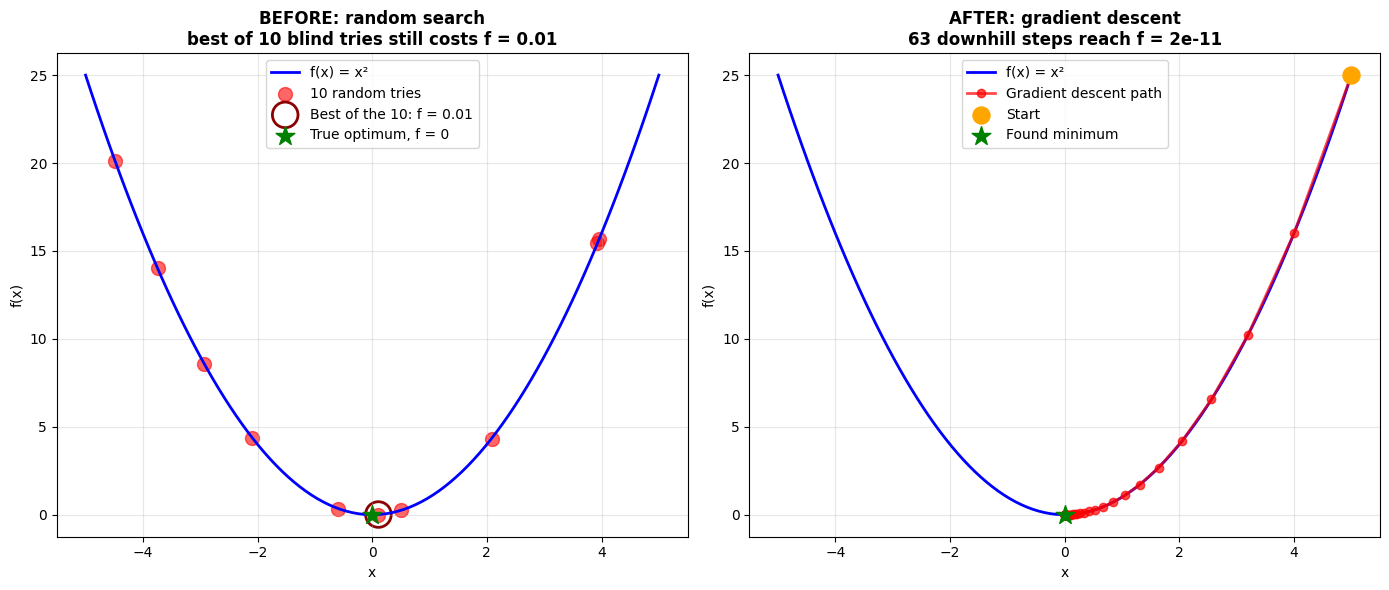

📊 BEFORE vs AFTER Comparison:
   BEFORE: Random search → Many tries, might miss optimum
   AFTER: Gradient descent → Systematic path directly to optimum!


In [4]:
# Compare the two strategies visually: random guessing vs the systematic downhill path gradient descent took.
import numpy as np
# Visualize: BEFORE vs AFTER comparison
# Show how gradient descent solves the problem

x_vals = np.linspace(-5, 5, 100)
y_vals = x_vals**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE: Random search (problematic)
ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = x²')
np.random.seed(3)                       # WHY: fix the 10 blind guesses so the picture is reproducible
random_x = np.random.uniform(-5, 5, 10)
random_y = random_x**2
best_rand = int(random_y.argmin())      # the LUCKIEST of the 10 random tries
ax1.scatter(random_x, random_y, color='red', s=100, alpha=0.6, label='10 random tries')
ax1.scatter([random_x[best_rand]], [random_y[best_rand]], facecolors='none',
            edgecolors='darkred', s=340, linewidths=2,
            label=f'Best of the 10: f = {random_y[best_rand]:.2f}')
ax1.scatter([0], [0], color='green', s=200, marker='*', zorder=5, label='True optimum, f = 0')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title(f'BEFORE: random search\nbest of 10 blind tries still costs f = {random_y[best_rand]:.2f}',
              fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AFTER: Gradient descent (solution)
ax2.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = x²')
if len(optimizer.history) > 0:
    path_x = [x[0] for x in optimizer.history]
    path_y = [f1(np.array([x])) for x in path_x]
    ax2.plot(path_x, path_y, 'r-o', linewidth=2, markersize=6, alpha=0.7, label='Gradient descent path')
    ax2.scatter([path_x[0]], [path_y[0]], color='orange', s=150, zorder=5, label='Start')
    ax2.scatter([path_x[-1]], [path_y[-1]], color='green', s=200, marker='*', zorder=5, label='Found minimum')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title(f'AFTER: gradient descent\n'
              f'{len(optimizer.history) - 1} downhill steps reach '
              f'f = {f1(np.array([optimizer.history[-1][0]])):.0e}', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 BEFORE vs AFTER Comparison:")
print("   BEFORE: Random search → Many tries, might miss optimum")
print("   AFTER: Gradient descent → Systematic path directly to optimum!")

## Part 2b: How big should each step be? The learning rate

The `GradientDescent` class above takes a `learning_rate` and its docstring says
*"too big = overshoot, too small = slow"*. That is the single most consequential
knob in this notebook — and in every neural network you will train later in this
diploma — so we are not going to take it on trust. We run the **same class, the
same function f(x) = x², the same starting point x = 5.0**, and change nothing
but the learning rate, then watch all four runs side by side.

One detail so the numbers line up: every run below is capped at exactly **25 steps**
and its early-stopping check is switched off, so we are always comparing step 12 of
one run against step 12 of another. (Part 2 let its run stop on its own, which took
63 steps — that is the same algorithm, just allowed to run to convergence.)


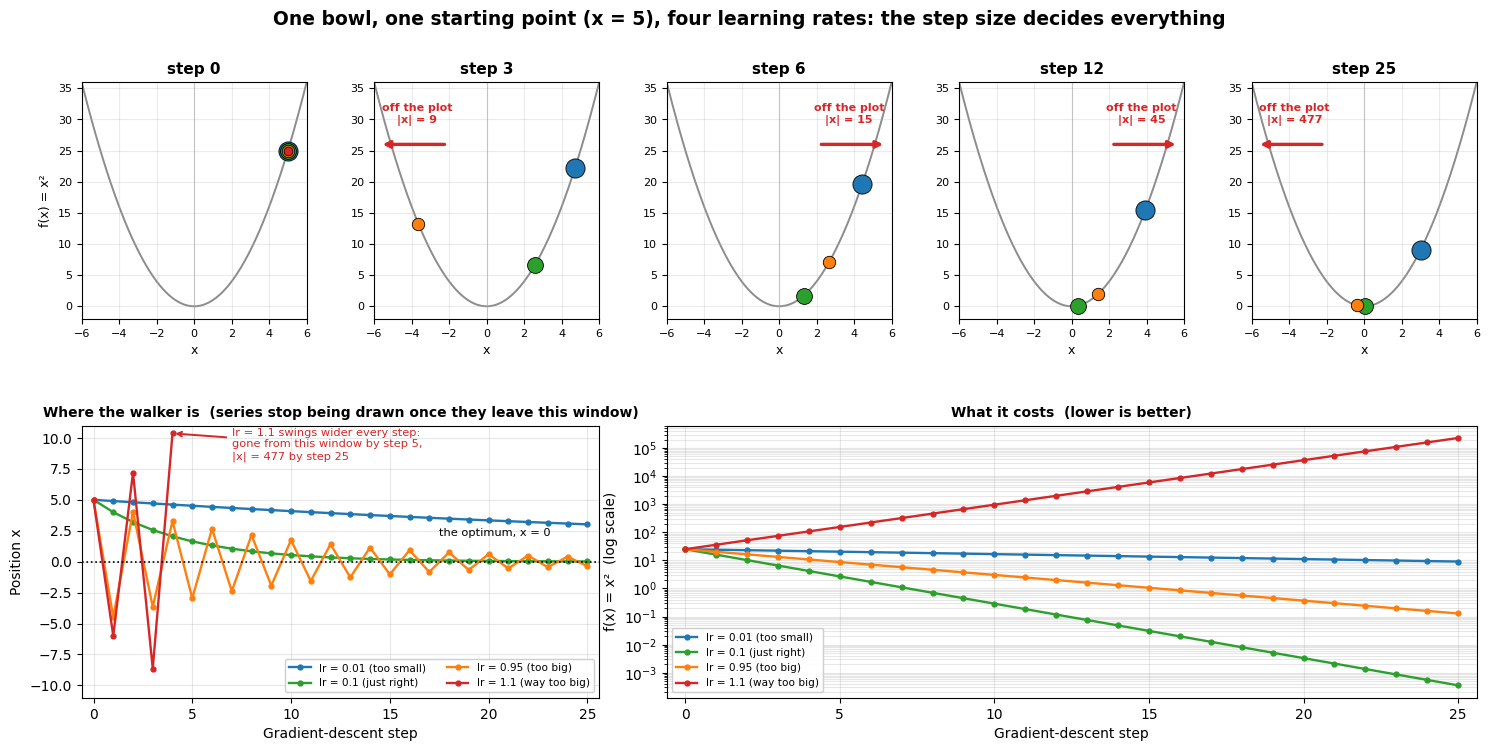

learning rate     x @ step 0   x @ step 3   x @ step 6  x @ step 12  x @ step 25   verdict
------------------------------------------------------------------------------------------
0.01                  5.0000       4.7060       4.4292       3.9236       3.0173   too small
0.10                  5.0000       2.5600       1.3107       0.3436       0.0189   just right
0.95                  5.0000      -3.6450       2.6572       1.4121      -0.3589   too big
1.10                  5.0000      -8.6400      14.9299      44.5805    -476.9810   way too big

Distance from the optimum after 25 steps:
   lr = 0.01  |x| =     3.0173   f(x) =   9.1042e+00   (too small)
   lr = 0.1   |x| =     0.0189   f(x) =   3.5681e-04   (just right)
   lr = 0.95  |x| =     0.3589   f(x) =   1.2884e-01   (too big)
   lr = 1.1   |x| =   476.9810   f(x) =   2.2751e+05   (way too big)


In [5]:
# Learning rate: the one knob that decides whether gradient descent works at all.
# WHAT: run the SAME GradientDescent class on the SAME bowl from the SAME start (x = 5),
#       changing ONLY the learning rate, and record every step of all four runs.
# WHY:  the class docstring claims "too big = overshoot, too small = slow". A claim a
#       student cannot see is a claim they cannot check. This draws it.
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt

N_STEPS = 25                       # Short run: enough to show the trend, cheap to render
FRAMES  = [0, 3, 6, 12, 25]        # The snapshots our storyboard row will show
RATES = [(0.01, 'too small',   'tab:blue'),
         (0.10, 'just right',  'tab:green'),
         (0.95, 'too big',     'tab:orange'),
         (1.10, 'way too big', 'tab:red')]

# Collect the full path of each run.
# tolerance=0.0 forces every run to take all N_STEPS steps, so the four paths stay
# step-for-step comparable (otherwise a fast run would stop early and the storyboard
# frames would compare step 12 of one run against the final step of another).
paths = {}
for lr, _label, _colour in RATES:
    runner = GradientDescent(learning_rate=lr, max_iterations=N_STEPS, tolerance=0.0)
    with contextlib.redirect_stdout(io.StringIO()):   # Mute the class's own per-step printing
        runner.optimize(f1, grad_f1, [5.0])           # Reuses f1 and grad_f1 from Part 2
    paths[lr] = np.array([h[0] for h in runner.history])

VIEW = 6.0    # x-range of the storyboard panels
YCAP = 11.0   # y-range of the position plot

fig = plt.figure(figsize=(15, 7.6))
gs = fig.add_gridspec(2, len(FRAMES), height_ratios=[1.0, 1.15], hspace=0.42, wspace=0.30)

# --- ROW 1: storyboard. One panel per step; four walkers on one bowl. ---
curve_x = np.linspace(-VIEW, VIEW, 300)
sizes = [190, 130, 80, 40]   # Descending marker sizes so overlapping walkers stay visible
for k, step in enumerate(FRAMES):
    ax = fig.add_subplot(gs[0, k])
    ax.plot(curve_x, curve_x**2, color='0.55', linewidth=1.4, zorder=1)
    for (lr, _label, colour), sz in zip(RATES, sizes):
        xs = paths[lr][step]
        if abs(xs) <= VIEW:
            ax.scatter([xs], [xs**2], color=colour, s=sz, zorder=4,
                       edgecolor='black', linewidth=0.6)
        else:
            # This walker has left the picture: say so and say how far out it is,
            # rather than silently dropping it.
            side = np.sign(xs)
            ax.annotate('', xy=(side * VIEW * 0.95, 26.0), xytext=(side * VIEW * 0.35, 26.0),
                        arrowprops=dict(arrowstyle='-|>', color=colour, linewidth=2.4))
            ax.text(side * VIEW * 0.62, 29.5, f'off the plot\n|x| = {abs(xs):.0f}',
                    color=colour, fontsize=8, ha='center', fontweight='bold')
    ax.axvline(0, color='0.8', linewidth=0.8, zorder=0)
    ax.set_xlim(-VIEW, VIEW); ax.set_ylim(-2, 36)
    ax.set_title(f'step {step}', fontsize=11, fontweight='bold')
    ax.set_xlabel('x', fontsize=9)
    if k == 0:
        ax.set_ylabel('f(x) = x²', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25)

# --- ROW 2 LEFT: position against step. Shows crawl / glide / zig-zag / blow-up. ---
axL = fig.add_subplot(gs[1, 0:2])
steps = np.arange(N_STEPS + 1)
for lr, label, colour in RATES:
    xs = paths[lr].astype(float).copy()
    # Stop drawing a run once it leaves the window, so a diverging run cannot smear
    # vertical bars across the three that stayed.
    off = np.abs(xs) > YCAP
    if off.any():
        xs[int(np.argmax(off)):] = np.nan
    axL.plot(steps, xs, 'o-', color=colour, markersize=3.5, linewidth=1.7,
             label=f'lr = {lr} ({label})')
axL.axhline(0, color='black', linestyle=':', linewidth=1.2)
axL.set_ylim(-YCAP, YCAP); axL.set_xlim(-0.6, N_STEPS + 0.6)
axL.set_xlabel('Gradient-descent step'); axL.set_ylabel('Position x')
axL.set_title('Where the walker is  (series stop being drawn once they leave this window)',
              fontsize=10, fontweight='bold')
axL.legend(fontsize=7.6, loc='lower right', ncol=2, framealpha=0.95)
axL.grid(True, alpha=0.3)

xs_div = paths[1.10]
step_off = int(np.argmax(np.abs(xs_div) > YCAP))
last_drawn = step_off - 1
axL.annotate(f'lr = 1.1 swings wider every step:\ngone from this window by step {step_off},\n'
             f'|x| = {abs(xs_div[-1]):.0f} by step {N_STEPS}',
             xy=(last_drawn, xs_div[last_drawn]), xytext=(7.0, 8.3),
             fontsize=8.2, color='tab:red', ha='left',
             arrowprops=dict(arrowstyle='->', color='tab:red', linewidth=1.4))
axL.text(17.5, 2.1, 'the optimum, x = 0', fontsize=8.2, color='black')

# --- ROW 2 RIGHT: the same four runs as COST. Log axis, so all four fit one scale. ---
axR = fig.add_subplot(gs[1, 2:])
for lr, label, colour in RATES:
    axR.semilogy(steps, np.maximum(paths[lr]**2, 1e-14), 'o-', color=colour,
                 markersize=3.5, linewidth=1.7, label=f'lr = {lr} ({label})')
axR.set_xlim(-0.6, N_STEPS + 0.6)
axR.set_xlabel('Gradient-descent step'); axR.set_ylabel('f(x) = x²  (log scale)')
axR.set_title('What it costs  (lower is better)', fontsize=10, fontweight='bold')
axR.legend(fontsize=7.6, loc='lower left', framealpha=0.95)
axR.grid(True, alpha=0.3, which='both')

fig.suptitle('One bowl, one starting point (x = 5), four learning rates: '
             'the step size decides everything', fontweight='bold', fontsize=13.5)
fig.subplots_adjust(top=0.885, bottom=0.075, left=0.055, right=0.985)
plt.show()

# The numbers behind the storyboard frames, so the picture can be checked digit by digit.
header = f'{"learning rate":<15}' + ''.join(f'{"x @ step " + str(s):>13}' for s in FRAMES) + '   verdict'
print(header)
print('-' * len(header))
for lr, label, _colour in RATES:
    row = f'{lr:<15.2f}' + ''.join(f'{paths[lr][s]:>13.4f}' for s in FRAMES)
    print(row + f'   {label}')
print()
print(f"Distance from the optimum after {N_STEPS} steps:")
for lr, label, _colour in RATES:
    print(f"   lr = {lr:<5} |x| = {abs(paths[lr][-1]):>10.4f}   f(x) = {paths[lr][-1]**2:>12.4e}   ({label})")


**Read the figure.** All four runs start on the same spot — at *step 0* the four
dots sit exactly on top of each other at x = 5, which is why that panel shows one
nest of rings rather than four separate dots. From there they separate completely:

- **lr = 0.01 (blue) — too small.** It moves downhill correctly, but barely. After 25
  steps it is still at x = 3.02, having covered under 40% of the distance to 0. Nothing
  is wrong with it; there is just not enough of it. On the cost plot it is the nearly
  flat blue line.
- **lr = 0.1 (green) — just right.** A smooth glide, no overshoot, and by step 25 it is
  at x = 0.019 with a cost of 3.6e-04 — the lowest of the four, about 360× below the
  next best run (lr = 0.95, cost 0.129).
- **lr = 0.95 (orange) — too big.** Watch the storyboard: at step 3 it is at −3.65, on the
  **opposite side** of the bowl from where it started. It jumps *past* the bottom on every
  single step and zig-zags in, which the position plot shows as the alternating orange
  sawtooth. It does still converge — but after 25 steps it sits at |x| = 0.359, about
  19× further from the optimum than lr = 0.1 for exactly the same 25 steps of work.
- **lr = 1.1 (red) — way too big.** The overshoot now grows instead of shrinking. It is
  off the storyboard panel by step 3, out of the position window by step 5, and at
  |x| = 477 by step 25. Its cost curve is the only one going **up**: from 25 to 2.3e+05.

**What this proves:** the learning rate is not a minor tuning detail. Holding the
function, the code and the starting point fixed, it is the difference between reaching
the answer, crawling toward it, wobbling toward it, and flying away from it. The two
failure modes are not symmetric either — too small merely wastes time, while too big
destroys the run.


## Part 3: Genetic Algorithms

**The Story**: Nature uses evolution to find good solutions — can we do the same?

**BEFORE**: Gradient descent needs a slope to follow, and on bumpy functions it can get stuck in local minima (we will *demonstrate* that in Part 4).
**AFTER**: Genetic algorithms need NO slope at all — a *population* of candidate solutions evolves through selection, crossover, and mutation.

The demo below runs a GA on the simple bowl f(x, y) = x² + y² so the mechanics are easy to watch. On this convex function gradient descent would work too — the GA's real advantage appears on functions with many local minima, or with no usable gradient at all.


✅ AFTER: Genetic Algorithms (Evolution-Based Optimization)

✅ Created Genetic Algorithm (population: 50, mutation: 10%)

📊 Problem: Minimize f(x, y) = x² + y²
   Optimal solution: (0, 0) with value 0

  ✅ Initialized population of 50 random solutions

🚀 Evolving population for 50 generations...

   Generation 0: Best fitness = 0.576709, Solution = [ 0.22732829 -0.72458982]
   Generation 10: Best fitness = 0.000857, Solution = [-0.0290871 -0.0033268]
   Generation 20: Best fitness = 0.000857, Solution = [-0.0290871 -0.0033268]
   Generation 30: Best fitness = 0.000021, Solution = [0.0037482 0.002657 ]
   Generation 40: Best fitness = 0.000008, Solution = [-0.00051731 -0.00280778]

✅ Evolution complete!
   Best solution: [-0.00051731 -0.00280778]
   Best fitness: 0.000008

🔗 WHAT THIS DEMONSTRATED (numbers computed above):
   • The GA reached fitness 0.000008 at [-0.0005 -0.0028]
     using NO gradient information at all
   • Selection + crossover exploit good candidates; mutation explor

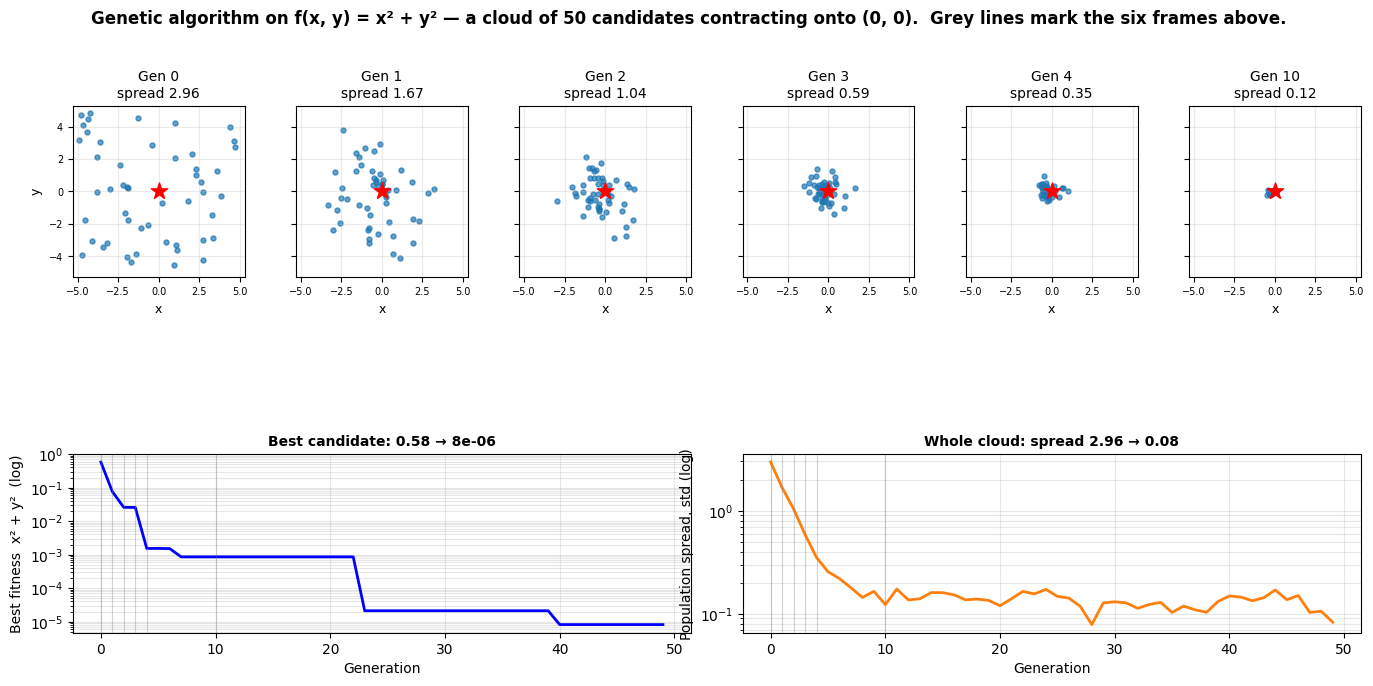


📊 GRADIENT DESCENT vs GENETIC ALGORITHM:
   Gradient descent: a single path that follows the measured slope (needs one)
   Genetic algorithm: a population of candidates - needs NO slope at all


In [6]:
# Genetic Algorithms: Evolution-Based Optimization
# Gradient-FREE global search: evolve a POPULATION of candidate solutions.
# (Demo on a simple convex bowl so the mechanics are easy to watch.)

import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(42)   # Reproducible evolution
random.seed(42)

class GeneticAlgorithm:
    """
    Genetic Algorithm: Evolution-based optimization.
    
    THE PROBLEM: Some objectives have no usable gradient, or many local minima.
    THE SOLUTION: Evolve solutions like nature - selection, crossover, mutation!
    
    How it works (like evolution):
    1. Create population of random solutions
    2. Evaluate fitness of each solution
    3. Select best solutions (survival of the fittest)
    4. Create new solutions (crossover and mutation)
    5. Repeat until we find optimal solution
    """
    def __init__(self, population_size=50, mutation_rate=0.1):
        """
        Initialize genetic algorithm.
        
        Parameters:
        - population_size: Number of solutions in each generation
        - mutation_rate: Probability of mutation (exploration)
        """
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.population = []
        self.fitness_history = []
        self.population_history = []   # snapshot of the WHOLE population each generation
        print(f"✅ Created Genetic Algorithm (population: {population_size}, mutation: {mutation_rate:.0%})")
    
    def initialize_population(self, bounds, n_dimensions):
        """
        Create initial population of random solutions.
        
        Parameters:
        - bounds: (min, max) tuple for each dimension
        - n_dimensions: Number of dimensions
        """
        self.population = []
        self.population_history = []   # fresh storyboard for this run
        for _ in range(self.population_size):
            # Create random solution
            individual = np.random.uniform(bounds[0], bounds[1], n_dimensions)
            self.population.append(individual)
        print(f"  ✅ Initialized population of {self.population_size} random solutions")
    
    def fitness_function(self, individual):
        """
        Calculate fitness of a solution (how good is it?).
        
        Lower value = better fitness (we're minimizing)
        """
        # Example: Minimize x² + y² (distance from origin)
        return np.sum(individual**2)
    
    def select_parents(self, fitness_scores):
        """
        Select parents for next generation (survival of the fittest).
        
        Better solutions have a higher chance of being selected!
        This is how evolution works - fitter individuals survive.
        """
        # Convert fitness to selection probability (lower fitness = better)
        # Invert fitness (multiply by -1) and add offset to make all positive
        max_fitness = np.max(fitness_scores)
        selection_probs = max_fitness - fitness_scores + 1  # Invert and offset
        selection_probs /= np.sum(selection_probs)  # Normalize to probabilities
        
        # Select parents based on probability
        indices = np.random.choice(len(self.population), size=2, p=selection_probs, replace=False)
        return [self.population[i] for i in indices]
    
    def crossover(self, parent1, parent2):
        """
        Create child by combining two parents (genetic crossover).
        
        Combine good traits from both parents!
        Example: Child = 0.5 × Parent1 + 0.5 × Parent2
        """
        # Simple crossover: average of parents
        child = 0.5 * parent1 + 0.5 * parent2
        return child
    
    def mutate(self, individual, bounds):
        """
        Mutate individual to explore new solutions.
        
        Random changes keep the population exploring new candidates!
        """
        if random.random() < self.mutation_rate:
            # Add random noise to individual
            mutation = np.random.uniform(-0.5, 0.5, len(individual))
            individual = individual + mutation
            
            # Keep within bounds
            individual = np.clip(individual, bounds[0], bounds[1])
        
        return individual
    
    def evolve(self, bounds, n_dimensions, generations=50):
        """
        Evolve population for multiple generations.
        
        Let evolution search for a good solution - no gradients involved!
        """
        self.initialize_population(bounds, n_dimensions)
        
        print(f"\n🚀 Evolving population for {generations} generations...")
        print()
        
        for generation in range(generations):
            # Evaluate fitness of each individual
            fitness_scores = [self.fitness_function(ind) for ind in self.population]
            
            # Track best fitness
            best_fitness = np.min(fitness_scores)
            self.fitness_history.append(best_fitness)
            # Snapshot every candidate, not just the best one: a GA moves a CLOUD,
            # and the cloud contracting is the thing worth watching.
            self.population_history.append(np.array(self.population))
            
            if generation % 10 == 0:
                best_individual = self.population[np.argmin(fitness_scores)]
                print(f"   Generation {generation}: Best fitness = {best_fitness:.6f}, Solution = {best_individual}")
            
            # Create new population
            new_population = []
            
            # Keep best individual (elitism)
            best_idx = np.argmin(fitness_scores)
            new_population.append(self.population[best_idx].copy())
            
            # Create rest of population through crossover and mutation
            while len(new_population) < self.population_size:
                # Select parents
                parent1, parent2 = self.select_parents(fitness_scores)
                
                # Create child
                child = self.crossover(parent1, parent2)
                
                # Mutate child
                child = self.mutate(child, bounds)
                
                new_population.append(child)
            
            self.population = new_population
        
        # Find best solution
        final_fitness = [self.fitness_function(ind) for ind in self.population]
        best_idx = np.argmin(final_fitness)
        best_solution = self.population[best_idx]
        best_fitness = final_fitness[best_idx]
        
        print(f"\n✅ Evolution complete!")
        print(f"   Best solution: {best_solution}")
        print(f"   Best fitness: {best_fitness:.6f}")
        
        return best_solution, best_fitness

# Example: Finding minimum of x² + y²
print("=" * 70)
print("✅ AFTER: Genetic Algorithms (Evolution-Based Optimization)")
print("=" * 70)
print()

ga = GeneticAlgorithm(population_size=50, mutation_rate=0.1)

print("\n📊 Problem: Minimize f(x, y) = x² + y²")
print("   Optimal solution: (0, 0) with value 0")
print()

# Evolve solution
best_sol, best_fit = ga.evolve(bounds=(-5, 5), n_dimensions=2, generations=50)

print("\n🔗 WHAT THIS DEMONSTRATED (numbers computed above):")
print(f"   • The GA reached fitness {best_fit:.6f} at {np.round(best_sol, 4)}")
print("     using NO gradient information at all")
print("   • Selection + crossover exploit good candidates; mutation explores new ones")
print("   • Note: f(x, y) = x² + y² is a single convex bowl, so this demo shows the")
print("     MECHANICS. The advantage over gradient descent on bumpy functions is")
print("     demonstrated explicitly in Part 4 (simulated annealing vs. gradient descent).")

# ── STORYBOARD: watch the POPULATION contract onto the optimum ────────────────
# WHY a row of frames and not one curve: gradient descent walks a single path, but a
# genetic algorithm moves a whole CLOUD of candidates. Six snapshots show the cloud
# shrinking; the two curves underneath measure the same thing over all generations.
frame_gens = [g for g in [0, 1, 2, 3, 4, 10] if g < len(ga.population_history)]
n_f = len(frame_gens)

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, n_f, height_ratios=[1.25, 1.0], hspace=0.75, wspace=0.30)

for k, g in enumerate(frame_gens):
    ax = fig.add_subplot(gs[0, k])
    P = ga.population_history[g]                    # shape (population_size, 2)
    ax.scatter(P[:, 0], P[:, 1], s=13, color='tab:blue', alpha=0.7)
    ax.scatter([0], [0], marker='*', s=150, color='red', zorder=5)   # the optimum (0, 0)
    ax.set_xlim(-5.3, 5.3); ax.set_ylim(-5.3, 5.3); ax.set_aspect('equal')
    ax.set_title(f'Gen {g}\nspread {P.std():.2f}', fontsize=10)
    ax.set_xlabel('x', fontsize=9)
    ax.grid(True, alpha=0.25); ax.tick_params(labelsize=7)
    if k == 0:
        ax.set_ylabel('y', fontsize=9)
    else:
        ax.set_yticklabels([])

gens = np.arange(len(ga.fitness_history))
spread = np.array([P.std() for P in ga.population_history])
split = max(1, n_f // 2)

ax1 = fig.add_subplot(gs[1, :split])
ax1.semilogy(gens, np.array(ga.fitness_history) + 1e-12, 'b-', linewidth=2)
for g in frame_gens:
    ax1.axvline(g, color='grey', alpha=0.35, linewidth=0.8)
ax1.set_xlabel('Generation'); ax1.set_ylabel('Best fitness  x² + y²  (log)')
ax1.set_title(f'Best candidate: {ga.fitness_history[0]:.2f} \u2192 {ga.fitness_history[-1]:.0e}',
              fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')

ax2 = fig.add_subplot(gs[1, split:])
ax2.semilogy(gens, spread, color='tab:orange', linewidth=2)
for g in frame_gens:
    ax2.axvline(g, color='grey', alpha=0.35, linewidth=0.8)
ax2.set_xlabel('Generation'); ax2.set_ylabel('Population spread, std (log)')
ax2.set_title(f'Whole cloud: spread {spread[0]:.2f} \u2192 {spread[-1]:.2f}',
              fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

fig.suptitle('Genetic algorithm on f(x, y) = x\u00b2 + y\u00b2 \u2014 a cloud of 50 candidates '
             'contracting onto (0, 0).  Grey lines mark the six frames above.',
             fontweight='bold', fontsize=12)
fig.subplots_adjust(top=0.88, bottom=0.09, left=0.06, right=0.98)
plt.show()

print("\n📊 GRADIENT DESCENT vs GENETIC ALGORITHM:")
print("   Gradient descent: a single path that follows the measured slope (needs one)")
print("   Genetic algorithm: a population of candidates - needs NO slope at all")


## Part 4: Simulated Annealing

**The Story**: Metal annealing gradually cools to find optimal structure - can we use this idea?

**BEFORE**: Optimization algorithms might get stuck in local minima.
**AFTER**: Simulated annealing starts "hot" (explores widely) then "cools" (focuses) - escapes local minima!

✅ AFTER: Simulated Annealing

✅ Created Simulated Annealing (initial temp: 50, cooling: 0.95)

📊 Problem: Minimize f(x) = (x-2)² + 2sin(5x)
   This function has multiple local minima!
   Challenge: Escape local minima to find global minimum

--- Baseline: gradient descent on f(x) = (x-2)² + 2sin(5x), from x = 5.0 ---
🚀 Starting gradient descent from x = 5.00
   Learning rate: 0.01

   Step 1: x = 4.8409, gradient = 15.9120, f(x) = 6.4693
   Step 2: x = 4.7241, gradient = 11.6734, f(x) = 5.4244
   Step 3: x = 4.6638, gradient = 6.0358, f(x) = 5.1545
   Step 4: x = 4.6346, gradient = 2.9214, f(x) = 5.0905
   Step 5: x = 4.6198, gradient = 1.4758, f(x) = 5.0739
✅ Converged after 22 iterations!
   Found minimum at x = 4.602884
   Function value: f(4.602884) = 5.067374

   → Gradient descent settled at x = 4.6029 with f(x) = 5.0674

--- Simulated annealing on the same function, same start ---

🚀 Starting simulated annealing from [5.0]
   Initial cost: 8.7353

   Iteration 0: Cost = 6.8851, 

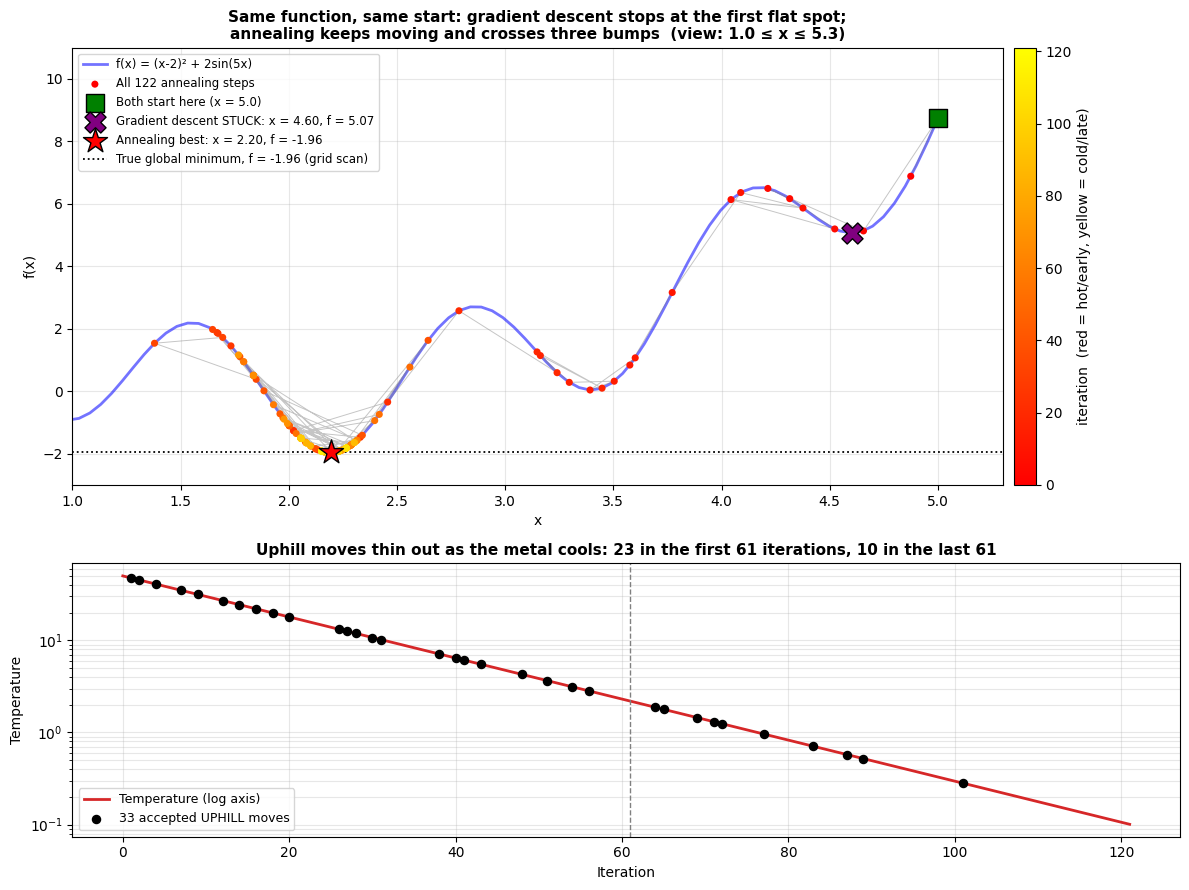


🔎 Grid-scan check (20,001 points): the true global minimum is f = -1.9619 at x = 2.1915.
   Annealing landed at x = 2.1972, i.e. 0.0057 away.
   The GRID told us that. The annealer itself never knows - see ⚠️ Where this breaks.

📊 BEFORE vs AFTER (this run):
   BEFORE: Gradient descent → stuck at f = 5.0674
   AFTER:  Simulated annealing → reached f = -1.9610


In [7]:
# Simulated annealing - accept some WORSE moves early (high temperature) to escape local minima.
import numpy as np
np.random.seed(42)  # Reproducible annealing run
# Simulated Annealing: Temperature-Based Optimization
# BEFORE: Optimization gets stuck in local minima
# AFTER: Start "hot" (explore widely), then "cool" (focus) - escapes local minima!

class SimulatedAnnealing:
    """
    Simulated Annealing: Temperature-based optimization.
    
    THE PROBLEM: Optimization algorithms get stuck in local minima.
    THE SOLUTION: Start "hot" (accept bad moves) then "cool" (be more selective)!
    
    Inspired by metal annealing: Hot metal can move freely, cooling allows structure to form.
    
    How it works:
    1. Start at high temperature (accept many moves)
    2. Make random move
    3. Accept better moves, sometimes accept worse moves (temperature-dependent)
    4. Gradually cool down (be more selective)
    5. Eventually find global optimum
    """
    def __init__(self, initial_temp=100, cooling_rate=0.95, min_temp=0.1):
        """
        Initialize simulated annealing.
        
        Parameters:
        - initial_temp: Starting temperature (high = explore more)
        - cooling_rate: How fast to cool (0.95 = 5% reduction each step)
        - min_temp: Minimum temperature (when to stop)
        """
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.min_temp = min_temp
        self.history = []  # Track our path (sparse: one entry per 50 iterations, for printing)
        self.full_trace = []  # EVERY iteration: (x, cost, temperature, accepted_uphill)
        self.iterations_run = 0  # Actual number of iterations executed
        print(f"✅ Created Simulated Annealing (initial temp: {initial_temp}, cooling: {cooling_rate:.2f})")
    
    def optimize(self, f, initial_solution, bounds, max_iterations=1000):
        """
        Optimize function using simulated annealing.
        
        THIS IS THE SOLUTION: Temperature helps escape local minima!
        """
        current_solution = np.array(initial_solution, dtype=float)
        current_cost = f(current_solution)
        best_solution = current_solution.copy()
        best_cost = current_cost
        
        temperature = self.initial_temp
        self.history = [(current_solution.copy(), current_cost, temperature)]
        self.full_trace = []   # fresh, complete record of this run
        
        print(f"\n🚀 Starting simulated annealing from {initial_solution}")
        print(f"   Initial cost: {current_cost:.4f}")
        print()
        
        for iteration in range(max_iterations):
            # Generate random neighbor (small random change)
            neighbor = current_solution + np.random.uniform(-0.5, 0.5, len(current_solution))
            
            # Keep within bounds
            neighbor = np.clip(neighbor, bounds[0], bounds[1])
            
            # Calculate cost of neighbor
            neighbor_cost = f(neighbor)
            
            # Decide whether to accept neighbor
            # Always accept if better
            # Sometimes accept if worse (probability depends on temperature)
            cost_diff = neighbor_cost - current_cost
            
            accepted_uphill = False  # did we just accept a move that made things WORSE?
            if cost_diff < 0:
                # Better solution - always accept
                current_solution = neighbor
                current_cost = neighbor_cost
                if neighbor_cost < best_cost:
                    best_solution = neighbor.copy()
                    best_cost = neighbor_cost
            else:
                # Worse solution - accept with probability
                # Probability = exp(-cost_diff / temperature)
                # Higher temperature = higher probability of accepting worse solution
                accept_prob = np.exp(-cost_diff / temperature)
                if np.random.random() < accept_prob:
                    current_solution = neighbor
                    current_cost = neighbor_cost
                    accepted_uphill = True   # exactly the move a greedy method would refuse
            
            # Record EVERY iteration (not only every 50th) together with the temperature
            # that governed it - otherwise the "path" we plot is a set of chords between
            # far-apart snapshots, which is not the walk the algorithm actually took.
            self.full_trace.append((current_solution[0], current_cost,
                                    temperature, accepted_uphill))
            
            # Cool down (reduce temperature)
            temperature *= self.cooling_rate
            
            # Track history
            if iteration % 50 == 0:
                self.history.append((current_solution.copy(), current_cost, temperature))
                print(f"   Iteration {iteration}: Cost = {current_cost:.4f}, Temp = {temperature:.2f}")
            
            # Stop if cooled enough
            if temperature < self.min_temp:
                print(f"\n✅ Cooled down (temp < {self.min_temp}) after {iteration + 1} iterations")
                break
        
        self.iterations_run = iteration + 1
        
        print(f"\n✅ Optimization complete!")
        print(f"   Best solution: {best_solution}")
        print(f"   Best cost: {best_cost:.6f}")
        
        return best_solution, best_cost

# Example: Finding minimum (with local minima)
def complex_function(x):
    """
    Complex function with local minima.
    
    f(x) = (x-2)² + 2*sin(5*x)
    Has multiple local minima - hard for gradient descent!
    
    Expects x as a numpy array (even for 1D).
    """
    x = np.asarray(x)  # Ensure it's an array
    return (x[0] - 2)**2 + 2 * np.sin(5 * x[0])

print("=" * 70)
print("✅ AFTER: Simulated Annealing")
print("=" * 70)
print()

sa = SimulatedAnnealing(initial_temp=50, cooling_rate=0.95, min_temp=0.1)

print("\n📊 Problem: Minimize f(x) = (x-2)² + 2sin(5x)")
print("   This function has multiple local minima!")
print("   Challenge: Escape local minima to find global minimum")
print()

# Baseline first: GRADIENT DESCENT on the same bumpy function, same start.
# (Reuses the GradientDescent class and numerical_gradient from Part 2.)
print("--- Baseline: gradient descent on f(x) = (x-2)² + 2sin(5x), from x = 5.0 ---")
gd_bumpy = GradientDescent(learning_rate=0.01, max_iterations=2000)
gd_sol, gd_cost = gd_bumpy.optimize(complex_function,
                                    lambda x: numerical_gradient(complex_function, x),
                                    [5.0])
print(f"\n   → Gradient descent settled at x = {gd_sol[0]:.4f} with f(x) = {gd_cost:.4f}")

# Now: SIMULATED ANNEALING on the same function, same start
print("\n--- Simulated annealing on the same function, same start ---")
best_sol, best_cost = sa.optimize(complex_function, [5.0], bounds=(-5, 5), max_iterations=500)

print("\n🔗 HOW THIS SOLVES THE PROBLEM (all numbers computed above):")
print(f"   • Gradient descent from x = 5.0 got stuck at    f = {gd_cost:.4f} (x = {gd_sol[0]:.4f})")
print(f"   • Simulated annealing from x = 5.0 found        f = {best_cost:.4f} (x = {best_sol[0]:.4f})")
if best_cost < gd_cost - 1e-3:
    print("   ✅ SA escaped the local minimum that trapped gradient descent:")
    print("      • Start hot: accept some uphill moves (explore widely)")
    print("      • Cool down: accept fewer uphill moves (focus on good regions)")
else:
    print("   ⚠️  On this run SA did not beat gradient descent — SA is stochastic.")
    print("      Re-run the cell or raise initial_temp to explore more.")

# Visualize
x_vals = np.linspace(-5, 5, 200)
y_vals = (x_vals - 2)**2 + 2 * np.sin(5 * x_vals)

# Two panels: WHERE the annealer walked, and WHY it was allowed to walk uphill.
trace_x  = np.array([t[0] for t in sa.full_trace])
trace_f  = np.array([t[1] for t in sa.full_trace])
trace_T  = np.array([t[2] for t in sa.full_trace])
trace_up = np.array([t[3] for t in sa.full_trace], dtype=bool)
steps    = np.arange(len(trace_x))

# Honest reference point: scan a fine grid for the TRUE global minimum.
# The annealer never gets to do this - we can, because the function is 1-D and cheap.
grid = np.linspace(-5, 5, 20001)
grid_f = (grid - 2)**2 + 2 * np.sin(5 * grid)
true_x, true_f = float(grid[grid_f.argmin()]), float(grid_f.min())

fig, (axA, axB) = plt.subplots(2, 1, figsize=(12, 9),
                               gridspec_kw={'height_ratios': [1.6, 1.0]})

# Panel A - the landscape, with EVERY annealing step plotted
axA.plot(x_vals, y_vals, 'b-', linewidth=2, alpha=0.55, label='f(x) = (x-2)\u00b2 + 2sin(5x)')
axA.plot(trace_x, trace_f, '-', color='grey', linewidth=0.7, alpha=0.45, zorder=2)
sc = axA.scatter(trace_x, trace_f, c=steps, cmap='autumn', s=26, zorder=3,
                 edgecolors='none', label=f'All {len(steps)} annealing steps')
plt.colorbar(sc, ax=axA, label='iteration  (red = hot/early, yellow = cold/late)', pad=0.01)
axA.scatter([5.0], [(5.0 - 2)**2 + 2 * np.sin(25.0)], color='green', s=180, marker='s',
            zorder=6, edgecolors='black', label='Both start here (x = 5.0)')
axA.scatter([gd_sol[0]], [gd_cost], color='purple', s=230, marker='X', zorder=6,
            edgecolors='black', label=f'Gradient descent STUCK: x = {gd_sol[0]:.2f}, f = {gd_cost:.2f}')
axA.scatter([best_sol[0]], [best_cost], color='red', s=330, marker='*', zorder=7,
            edgecolors='black', label=f'Annealing best: x = {best_sol[0]:.2f}, f = {best_cost:.2f}')
axA.axhline(true_f, color='black', linestyle=':', linewidth=1.3,
            label=f'True global minimum, f = {true_f:.2f} (grid scan)')
axA.set_xlim(1.0, 5.3); axA.set_ylim(-3, 11)
axA.set_xlabel('x'); axA.set_ylabel('f(x)')
axA.set_title('Same function, same start: gradient descent stops at the first flat spot;\n'
              'annealing keeps moving and crosses three bumps  (view: 1.0 \u2264 x \u2264 5.3)',
              fontweight='bold', fontsize=11)
axA.legend(fontsize=8.5, loc='upper left')
axA.grid(True, alpha=0.3)

# Panel B - the cooling schedule and the uphill moves it paid for
half = len(steps) // 2
n_up = int(trace_up.sum())
first_half, second_half = int(trace_up[:half].sum()), int(trace_up[half:].sum())
axB.semilogy(steps, trace_T, color='tab:red', linewidth=2, label='Temperature (log axis)')
axB.scatter(steps[trace_up], trace_T[trace_up], color='black', s=34, zorder=5,
            label=f'{n_up} accepted UPHILL moves')
axB.axvline(half, color='grey', linestyle='--', linewidth=1)
axB.set_xlabel('Iteration'); axB.set_ylabel('Temperature')
axB.set_title(f'Uphill moves thin out as the metal cools: {first_half} in the first {half} '
              f'iterations, {second_half} in the last {len(steps) - half}',
              fontweight='bold', fontsize=11)
axB.legend(fontsize=9, loc='lower left')
axB.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"\n\U0001F50E Grid-scan check (20,001 points): the true global minimum is "
      f"f = {true_f:.4f} at x = {true_x:.4f}.")
print(f"   Annealing landed at x = {best_sol[0]:.4f}, i.e. {abs(best_sol[0] - true_x):.4f} away.")
print("   The GRID told us that. The annealer itself never knows - see \u26a0\ufe0f Where this breaks.")

print("\n📊 BEFORE vs AFTER (this run):")
print(f"   BEFORE: Gradient descent → stuck at f = {gd_cost:.4f}")
print(f"   AFTER:  Simulated annealing → reached f = {best_cost:.4f}")

## Part 5: Hill Climbing

**The Story**: Sometimes the simplest approach works - just keep going uphill!

**BEFORE**: We need complex algorithms for optimization.
**AFTER**: Hill climbing is simple - just keep moving toward better solutions - but gets stuck in local optima!

✅ AFTER: Hill Climbing (Simple Optimization)

✅ Created Hill Climbing (step size: 0.1)

📊 Problem: Minimize f(x) = x²
   Starting from x = 5


🚀 Starting hill climbing from [5.0]
   Initial cost: 25.0000

   Iteration 0: Cost = 24.0100
   Iteration 1: Cost = 23.0400
   Iteration 2: Cost = 22.0900
   Iteration 3: Cost = 21.1600
   Iteration 4: Cost = 20.2500
   Iteration 10: Cost = 15.2100
   Iteration 20: Cost = 8.4100
   Iteration 30: Cost = 3.6100
   Iteration 40: Cost = 0.8100

✅ Optimization complete!
   Final solution: [1.0269563e-15]
   Final cost: 0.000000

🔗 HOW THIS WORKS:
   ✅ Simple: Always move toward better solution
   ✅ Works: For simple problems without local optima
   ⚠️  Limited: Gets stuck in local optima (that's why we need GA and SA!)

⚠️  SAME hill climber, bumpy function - watch it stop early
✅ Created Hill Climbing (step size: 0.1)

🚀 Starting hill climbing from [5.0]
   Initial cost: 8.7353

   Iteration 0: Cost = 7.2273
   Iteration 1: Cost = 6.0288
   Iteratio

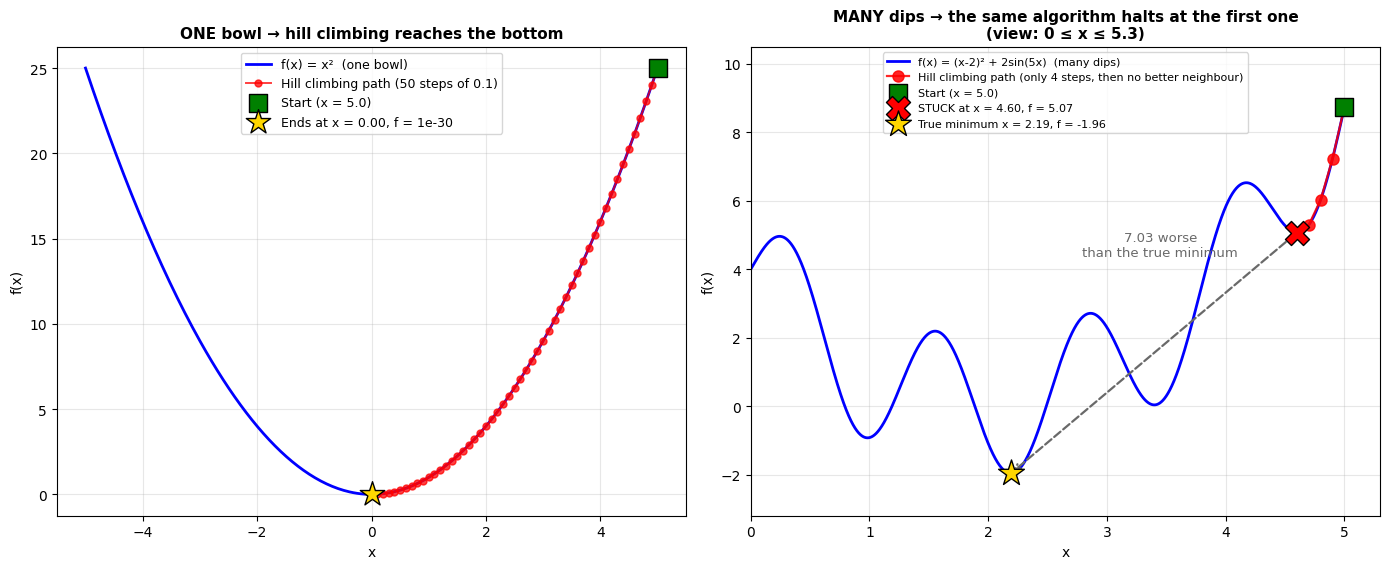


📊 Comparison with other methods:
   • Gradient Descent: Faster convergence, needs gradients
   • Hill Climbing: Simple, but gets stuck in local optima
   • Genetic Algorithm: Global search, escapes local optima
   • Simulated Annealing: Temperature-based, escapes local optima


In [8]:
# Hill climbing - the simplest local search: always step to the best neighbor, stop when none is better.
import numpy as np
# Hill Climbing: Simple but Limited Optimization
# BEFORE: Need complex algorithms for optimization
# AFTER: Simple approach - just go uphill - but limited (gets stuck in local optima)!

class HillClimbing:
    """
    Hill Climbing: Simple optimization algorithm.
    
    THE PROBLEM: We need to find maximum/minimum of a function.
    THE SOLUTION: Simple approach - always move toward better solution!
    
    How it works:
    1. Start at random point
    2. Generate neighbors (small changes)
    3. Move to best neighbor (if better)
    4. Repeat until no better neighbor found
    
    LIMITATION: Gets stuck in local optima (hills, not mountains)!
    That's why we have Genetic Algorithms and Simulated Annealing!
    """
    def __init__(self, step_size=0.1):
        """
        Initialize hill climbing.
        
        Parameters:
        - step_size: How big steps to take when exploring neighbors
        """
        self.step_size = step_size
        self.history = []
        print(f"✅ Created Hill Climbing (step size: {step_size})")
    
    def optimize(self, f, initial_solution, bounds, max_iterations=100):
        """
        Optimize function using hill climbing.
        
        THIS IS SIMPLE BUT LIMITED:
        - Simple: Easy to understand and implement
        - Limited: Gets stuck in local optima
        """
        current_solution = np.array(initial_solution, dtype=float)
        current_cost = f(current_solution)
        
        self.history = [(current_solution.copy(), current_cost)]
        
        print(f"\n🚀 Starting hill climbing from {initial_solution}")
        print(f"   Initial cost: {current_cost:.4f}")
        print()
        
        for iteration in range(max_iterations):
            # Generate neighbors (try small changes in each direction)
            best_neighbor = None
            best_neighbor_cost = current_cost
            
            # Try neighbors in all directions
            for i in range(len(current_solution)):
                # Try positive direction
                neighbor_pos = current_solution.copy()
                neighbor_pos[i] += self.step_size
                neighbor_pos = np.clip(neighbor_pos, bounds[0], bounds[1])
                cost_pos = f(neighbor_pos)
                
                # Try negative direction
                neighbor_neg = current_solution.copy()
                neighbor_neg[i] -= self.step_size
                neighbor_neg = np.clip(neighbor_neg, bounds[0], bounds[1])
                cost_neg = f(neighbor_neg)
                
                # Keep best neighbor
                if cost_pos < best_neighbor_cost:
                    best_neighbor = neighbor_pos
                    best_neighbor_cost = cost_pos
                if cost_neg < best_neighbor_cost:
                    best_neighbor = neighbor_neg
                    best_neighbor_cost = cost_neg
            
            # Move to best neighbor if it's better
            if best_neighbor_cost < current_cost:
                current_solution = best_neighbor
                current_cost = best_neighbor_cost
                self.history.append((current_solution.copy(), current_cost))
                
                if iteration < 5 or iteration % 10 == 0:
                    print(f"   Iteration {iteration}: Cost = {current_cost:.4f}")
            else:
                # No better neighbor - stuck at local optimum!
                print(f"\n⚠️  Stuck at local optimum after {iteration} iterations")
                print(f"   Final cost: {current_cost:.4f}")
                break
        
        print(f"\n✅ Optimization complete!")
        print(f"   Final solution: {current_solution}")
        print(f"   Final cost: {current_cost:.6f}")
        
        return current_solution, current_cost

# Example: Hill climbing on simple function
def simple_function(x):
    """Simple function: f(x) = x²
    
    Expects x as a numpy array (even for 1D).
    """
    x = np.asarray(x)  # Ensure it's an array
    if x.ndim == 0:  # Scalar
        return float(x)**2
    elif len(x) == 1:  # Single-element array (optimization use case)
        return x[0]**2
    else:  # Multi-element array
        return x**2

print("=" * 70)
print("✅ AFTER: Hill Climbing (Simple Optimization)")
print("=" * 70)
print()

hc = HillClimbing(step_size=0.1)

print("\n📊 Problem: Minimize f(x) = x²")
print("   Starting from x = 5")
print()

# Optimize
solution, cost = hc.optimize(simple_function, [5.0], bounds=(-5, 5), max_iterations=50)

print("\n🔗 HOW THIS WORKS:")
print("   ✅ Simple: Always move toward better solution")
print("   ✅ Works: For simple problems without local optima")
print("   ⚠️  Limited: Gets stuck in local optima (that's why we need GA and SA!)")

# "Simple but gets stuck" is only worth saying if we SHOW it stuck. So run the SAME
# hill climber, from the SAME start x = 5.0, on a function with several dips.
def bumpy(x):
    """Many local minima: f(x) = (x-2)\u00b2 + 2sin(5x). Expects a 1-element array."""
    x = np.asarray(x)
    return (x[0] - 2)**2 + 2 * np.sin(5 * x[0])

print("\n" + "=" * 70)
print("\u26a0\ufe0f  SAME hill climber, bumpy function - watch it stop early")
print("=" * 70)
hc_bumpy = HillClimbing(step_size=0.1)
sol_b, cost_b = hc_bumpy.optimize(bumpy, [5.0], bounds=(-5, 5), max_iterations=50)

# Honest reference: the true global minimum, from a fine grid scan (cheap in 1-D).
grid = np.linspace(-5, 5, 20001)
grid_f = (grid - 2)**2 + 2 * np.sin(5 * grid)
true_x, true_f = float(grid[grid_f.argmin()]), float(grid_f.min())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.8))

# LEFT - one smooth bowl: hill climbing walks all the way down
x_vals = np.linspace(-5, 5, 300)
axL.plot(x_vals, x_vals**2, 'b-', linewidth=2, label='f(x) = x\u00b2  (one bowl)')
path_x = [s[0] for s, c in hc.history]
path_y = [x**2 for x in path_x]
axL.plot(path_x, path_y, 'ro-', linewidth=1.4, markersize=5, alpha=0.75,
         label=f'Hill climbing path ({len(path_x) - 1} steps of 0.1)')
axL.scatter([path_x[0]], [path_y[0]], color='green', s=180, marker='s', zorder=5,
            edgecolors='black', label='Start (x = 5.0)')
axL.scatter([path_x[-1]], [path_y[-1]], color='gold', s=340, marker='*', zorder=6,
            edgecolors='black', label=f'Ends at x = {path_x[-1]:.2f}, f = {path_y[-1]:.1g}')
axL.set_xlabel('x'); axL.set_ylabel('f(x)')
axL.set_title('ONE bowl \u2192 hill climbing reaches the bottom', fontweight='bold', fontsize=11)
axL.legend(fontsize=9, loc='upper center'); axL.grid(True, alpha=0.3)

# RIGHT - many dips: the SAME algorithm halts at the first one it meets
axR.plot(grid, grid_f, 'b-', linewidth=2, label='f(x) = (x-2)\u00b2 + 2sin(5x)  (many dips)')
pb_x = [s[0] for s, c in hc_bumpy.history]
pb_y = [(x - 2)**2 + 2 * np.sin(5 * x) for x in pb_x]
axR.plot(pb_x, pb_y, 'ro-', linewidth=1.6, markersize=8, alpha=0.85,
         label=f'Hill climbing path (only {len(pb_x) - 1} steps, then no better neighbour)')
axR.scatter([pb_x[0]], [pb_y[0]], color='green', s=180, marker='s', zorder=5,
            edgecolors='black', label='Start (x = 5.0)')
axR.scatter([pb_x[-1]], [pb_y[-1]], color='red', s=300, marker='X', zorder=6,
            edgecolors='black', label=f'STUCK at x = {pb_x[-1]:.2f}, f = {cost_b:.2f}')
axR.scatter([true_x], [true_f], color='gold', s=380, marker='*', zorder=6,
            edgecolors='black', label=f'True minimum x = {true_x:.2f}, f = {true_f:.2f}')
axR.annotate('', xy=(true_x, true_f), xytext=(pb_x[-1], pb_y[-1]),
             arrowprops=dict(arrowstyle='->', color='dimgrey', linestyle='--', linewidth=1.6))
axR.text(3.45, 4.4, f'{cost_b - true_f:.2f} worse\nthan the true minimum',
         ha='center', fontsize=9.5, color='dimgrey')
axR.set_xlim(0, 5.3); axR.set_ylim(-3.2, 10.5)
axR.set_xlabel('x'); axR.set_ylabel('f(x)')
axR.set_title('MANY dips \u2192 the same algorithm halts at the first one\n(view: 0 \u2264 x \u2264 5.3)',
              fontweight='bold', fontsize=11)
axR.legend(fontsize=8, loc='upper center'); axR.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Comparison with other methods:")
print("   • Gradient Descent: Faster convergence, needs gradients")
print("   • Hill Climbing: Simple, but gets stuck in local optima")
print("   • Genetic Algorithm: Global search, escapes local optima")
print("   • Simulated Annealing: Temperature-based, escapes local optima")

## Part 6: Real-World Application: Training ML Models

**The Story**: Machine learning models need optimization to learn - this is where everything connects!

**BEFORE**: We train models manually or randomly - very slow and inefficient.
**AFTER**: We use optimization algorithms (gradient descent) to train models automatically - fast and efficient!

✅ AFTER: Real-World Application - Training ML Models

📊 REAL-LIFE EXAMPLE: Training a Machine Learning Model
   Problem: Model needs to learn optimal parameters
   Solution: Use optimization (gradient descent) to find best parameters!

crime_statistics_original_50: full file, 50 rows.
📊 Step 1: We have REAL training data
   • Dataset: US Crime Statistics (USArrests) — arrests per 100,000 residents
   • 50 examples (one per US state)
   • Features: 1 (Assault arrest rate)
   • Target: Murder arrest rate, real range 0.8 to 17.4
   • Correlation between the two in the real data: 0.802

📊 Step 2: Model needs to learn parameters
   • Linear model: murder_rate = w × assault_rate + b
   • Need to find: w (weight) and b (bias)
   • This is an OPTIMIZATION PROBLEM!

📊 Step 3: Model learns using optimization (gradient descent)
   ✅ Learned weight: w = 0.0419
   ✅ Learned bias: b = 0.6317

📊 Step 4: Model can now make predictions!
   ✅ Model learned the pattern from real data
   ✅ R² on the 50 re

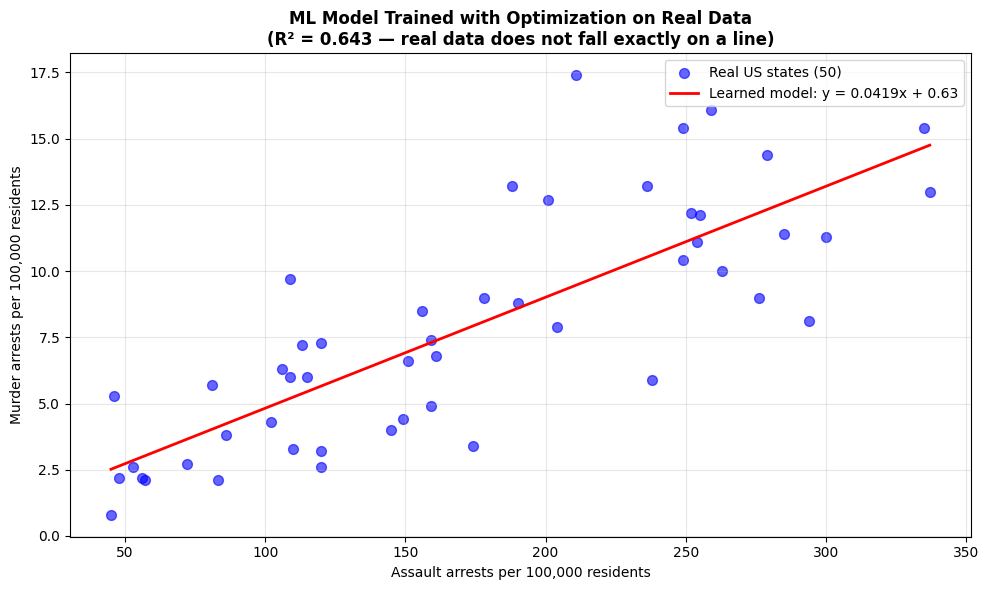

🔗 HOW THIS CONNECTS TO REAL LIFE:
   • Neural Networks: Use gradient descent to learn weights
   • Recommendation Systems: Optimize to recommend best items
   • Computer Vision: Optimize to recognize images
   • Natural Language Processing: Optimize to understand language

📊 BEFORE vs AFTER:
   BEFORE: Train models manually → Very slow, might not converge
   AFTER: Use optimization → Fast, automatic, finds optimal parameters!

🔗 CONNECTION TO NOTEBOOK 5:
   This is exactly what machine learning models do - they use
   optimization (from this notebook) to learn from data!


In [9]:
# Real-World Application: Training ML Models with Optimization
# BEFORE: Train models manually or randomly - very slow
# AFTER: Use optimization to train models automatically - fast and efficient!

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("✅ AFTER: Real-World Application - Training ML Models")
print("=" * 70)
print()

print("📊 REAL-LIFE EXAMPLE: Training a Machine Learning Model")
print("   Problem: Model needs to learn optimal parameters")
print("   Solution: Use optimization (gradient descent) to find best parameters!")
print()

# REAL DATA: the classic US Crime Statistics table (USArrests) — arrests per 100,000
# residents in each of the 50 US states. Every number was collected, not generated.
crime = load("crime_statistics_original_50")

# We ask a real question: can a state's assault-arrest rate predict its murder-arrest rate?
X = crime[["Assault"]].to_numpy()      # feature: assault arrests per 100,000
y = crime["Murder"].to_numpy()         # target:  murder arrests per 100,000

print("📊 Step 1: We have REAL training data")
print(f"   • Dataset: US Crime Statistics (USArrests) — arrests per 100,000 residents")
print(f"   • {len(X)} examples (one per US state)")
print(f"   • Features: {X.shape[1]} (Assault arrest rate)")
print(f"   • Target: Murder arrest rate, real range {y.min():.1f} to {y.max():.1f}")
print(f"   • Correlation between the two in the real data: "
      f"{np.corrcoef(X.ravel(), y)[0, 1]:.3f}")
print()

print("📊 Step 2: Model needs to learn parameters")
print("   • Linear model: murder_rate = w × assault_rate + b")
print("   • Need to find: w (weight) and b (bias)")
print("   • This is an OPTIMIZATION PROBLEM!")
print()

# Train model (this uses optimization internally!)
model = LinearRegression()
model.fit(X, y)

print("📊 Step 3: Model learns using optimization (gradient descent)")
print(f"   ✅ Learned weight: w = {model.coef_[0]:.4f}")
print(f"   ✅ Learned bias: b = {model.intercept_:.4f}")
print()

# Make predictions
y_pred = model.predict(X)
r2 = model.score(X, y)
rmse = float(np.sqrt(((y - y_pred) ** 2).mean()))

print("📊 Step 4: Model can now make predictions!")
print(f"   ✅ Model learned the pattern from real data")
print(f"   ✅ R² on the 50 real states: {r2:.4f}")
print(f"   ✅ Typical error (RMSE): {rmse:.2f} murder arrests per 100,000")
print(f"   ✅ Reading the weight: every extra 100 assault arrests per 100,000 goes with")
print(f"      about {model.coef_[0] * 100:.2f} more murder arrests per 100,000")
print()
print("   ⚠️  Correlation is not causation. Optimization found the line that fits these")
print("      real numbers best; it did not discover why the two rates move together.")
print()

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', s=50, label='Real US states (50)')
order = X.ravel().argsort()
plt.plot(X.ravel()[order], y_pred[order], 'r-', linewidth=2,
         label=f'Learned model: y = {model.coef_[0]:.4f}x + {model.intercept_:.2f}')
plt.xlabel('Assault arrests per 100,000 residents')
plt.ylabel('Murder arrests per 100,000 residents')
plt.title(f'ML Model Trained with Optimization on Real Data\n'
          f'(R² = {r2:.3f} — real data does not fall exactly on a line)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🔗 HOW THIS CONNECTS TO REAL LIFE:")
print("   • Neural Networks: Use gradient descent to learn weights")
print("   • Recommendation Systems: Optimize to recommend best items")
print("   • Computer Vision: Optimize to recognize images")
print("   • Natural Language Processing: Optimize to understand language")
print()
print("📊 BEFORE vs AFTER:")
print("   BEFORE: Train models manually → Very slow, might not converge")
print("   AFTER: Use optimization → Fast, automatic, finds optimal parameters!")
print()
print("🔗 CONNECTION TO NOTEBOOK 5:")
print("   This is exactly what machine learning models do - they use")
print("   optimization (from this notebook) to learn from data!")


## Part 7: Practice: Comparing Optimization Methods

**The Story**: Now let's compare all optimization methods side-by-side!

**BEFORE**: We've seen individual methods, but not how they compare.
**AFTER**: We compare gradient descent, genetic algorithms, simulated annealing, and hill climbing - see which works best!

✅ AFTER: Comparing All Optimization Methods

📊 Problem: Minimize f(x) = x²
   Starting from x = 5
   Optimal solution: x = 0 (value = 0)

🔍 Testing Gradient Descent:
🚀 Starting gradient descent from x = 5.00
   Learning rate: 0.1

   Step 1: x = 4.0000, gradient = 10.0000, f(x) = 16.0000
   Step 2: x = 3.2000, gradient = 8.0000, f(x) = 10.2400
   Step 3: x = 2.5600, gradient = 6.4000, f(x) = 6.5536
   Step 4: x = 2.0480, gradient = 5.1200, f(x) = 4.1943
   Step 5: x = 1.6384, gradient = 4.0960, f(x) = 2.6844
   Step 51: x = 0.0001, gradient = 0.0001, f(x) = 0.0000
✅ Converged after 63 iterations!
   Found minimum at x = 0.000004
   Function value: f(0.000004) = 0.000000

🔍 Testing Hill Climbing:
✅ Created Hill Climbing (step size: 0.1)

🚀 Starting hill climbing from [5.0]
   Initial cost: 25.0000

   Iteration 0: Cost = 24.0100
   Iteration 1: Cost = 23.0400
   Iteration 2: Cost = 22.0900
   Iteration 3: Cost = 21.1600
   Iteration 4: Cost = 20.2500
   Iteration 10: Cost = 15.2100
   I

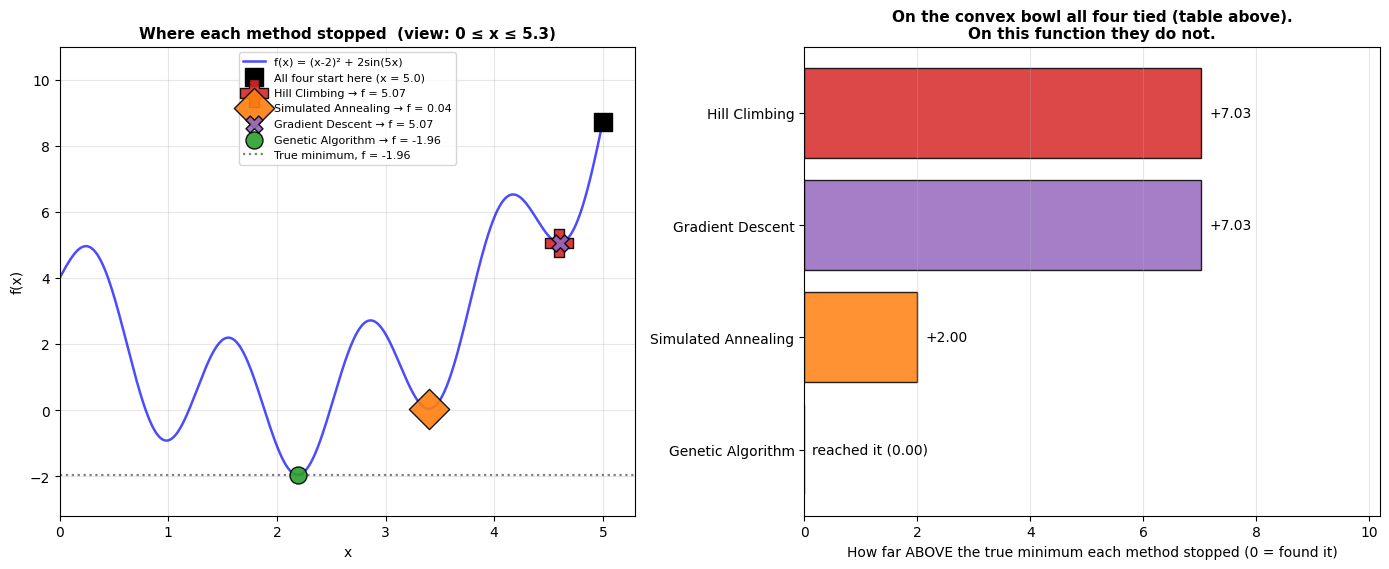


🔎 Read the picture: the LEFT panel puts all four stopping points on the
   same curve, so you can see WHERE each one gave up; the RIGHT panel turns that
   into one number each - how far above the true minimum they stopped.
   Hill climbing and gradient descent land on the SAME spot (x = 4.60) and so
   share the same +7.03 bar: both are local methods that walk downhill from
   x = 5.0 and halt at the first flat place they meet. Only the two methods that
   are allowed to move the WRONG way on purpose - annealing's uphill moves and
   the genetic algorithm's population - get past that first dip.


In [10]:
# Practice: Comparing All Optimization Methods
# BEFORE: Individual methods, but not how they compare
# AFTER: Compare all methods side-by-side - see which works best!
#
# NOTE: This cell requires the optimization classes defined earlier:
# GradientDescent (Part 2), GeneticAlgorithm (Part 3),
# SimulatedAnnealing (Part 4), HillClimbing (Part 5).
# Make sure to run those cells first!

import numpy as np
import matplotlib.pyplot as plt
import time
import random

np.random.seed(7)   # Reproducible comparison run
random.seed(7)

print("=" * 70)
print("✅ AFTER: Comparing All Optimization Methods")
print("=" * 70)
print()

# Test function: f(x) = x² (simple function)
def test_function(x):
    """Simple test function: f(x) = x²
    
    Expects x as a numpy array (even for 1D).
    This is consistent with how optimization methods use it.
    """
    x = np.asarray(x)  # Ensure it's an array
    # Handle both 0-d (scalar) and 1-d arrays
    if x.ndim == 0:  # Scalar converted to 0-d array
        return float(x)**2
    elif len(x) == 1:  # Single-element array (optimization use case)
        return x[0]**2
    else:  # Multi-element array
        return x**2

def grad_test_function(x):
    """Slope of the test function, MEASURED numerically (see Part 2 - no calculus needed)."""
    return numerical_gradient(test_function, x)

print("📊 Problem: Minimize f(x) = x²")
print("   Starting from x = 5")
print("   Optimal solution: x = 0 (value = 0)")
print()

# Run each method
results = {}

print("🔍 Testing Gradient Descent:")
start_time = time.time()
gd = GradientDescent(learning_rate=0.1, max_iterations=100)
gd_solution, gd_final_cost = gd.optimize(test_function, grad_test_function, [5.0])
gd_time = time.time() - start_time
results['Gradient Descent'] = {
    'solution': gd_solution[0], 'cost': gd_final_cost,
    'time': gd_time,
    'iterations': len(gd.history) - 1
}

print("\n🔍 Testing Hill Climbing:")
start_time = time.time()
hc = HillClimbing(step_size=0.1)
hc_solution, hc_cost = hc.optimize(test_function, [5.0], bounds=(-5, 5), max_iterations=50)
hc_time = time.time() - start_time
results['Hill Climbing'] = {
    'solution': hc_solution[0], 'cost': hc_cost,
    'time': hc_time,
    'iterations': len(hc.history) - 1
}

print("\n🔍 Testing Genetic Algorithm:")
start_time = time.time()
ga = GeneticAlgorithm(population_size=30, mutation_rate=0.1)
ga_solution, ga_fitness = ga.evolve(bounds=(-5, 5), n_dimensions=1, generations=30)
ga_time = time.time() - start_time
results['Genetic Algorithm'] = {
    'solution': ga_solution[0], 'cost': ga_fitness,
    'time': ga_time,
    'iterations': 30
}

print("\n🔍 Testing Simulated Annealing:")
start_time = time.time()
sa = SimulatedAnnealing(initial_temp=50, cooling_rate=0.95, min_temp=0.1)
sa_solution, sa_cost = sa.optimize(test_function, [5.0], bounds=(-5, 5), max_iterations=200)
sa_time = time.time() - start_time
results['Simulated Annealing'] = {
    'solution': sa_solution[0], 'cost': sa_cost,
    'time': sa_time,
    'iterations': sa.iterations_run
}

# Compare results
print("\n" + "=" * 70)
print("📊 COMPARISON OF ALL OPTIMIZATION METHODS")
print("=" * 70)
print()
print(f"{'Method':<25} {'Solution':<15} {'Final Cost':<15} {'Time (s)':<12} {'Iterations':<12}")
print("-" * 85)

for method, result in results.items():
    print(f"{method:<25} {result['solution']:<15.6f} {result['cost']:<15.6f} {result['time']:<12.4f} {result['iterations']:<12}")

print()
# Key insights COMPUTED from this run's table (not assumed):
fastest = min(results, key=lambda m: results[m]['time'])
slowest = max(results, key=lambda m: results[m]['time'])
worst_cost = max(r['cost'] for r in results.values())
print("✅ Key Insights (computed from THIS run):")
print(f"   • All four methods solved this convex function: every final cost ≤ {worst_cost:.6f}")
print(f"   • Fastest here: {fastest} ({results[fastest]['time']:.4f}s)")
print(f"   • Slowest here: {slowest} ({results[slowest]['time']:.4f}s) — it evaluates a whole")
print("     population's fitness every generation")
print("   • Speed on an easy convex bowl is NOT the whole story: the methods differ most")
print("     on bumpy functions — Part 4 showed gradient descent trapped in a local")
print("     minimum that simulated annealing escaped")
print()
print("🔗 HOW TO CHOOSE IN REAL LIFE:")
print("   • Simple smooth function → Gradient Descent (reliable, converges quickly)")
print("   • Many local minima → Genetic Algorithm or Simulated Annealing")
print("   • Quick solution needed → Hill Climbing (simplest)")
print("   • Need global optimum → Genetic Algorithm or Simulated Annealing")

# ── The picture the table above cannot draw ───────────────────────────────────
# The table ranked four methods on a CONVEX bowl, where all four win, so it cannot
# separate them. The advice just printed only earns its place on a BUMPY function,
# so run the same four there, from the same start, and plot where each one lands.
np.random.seed(11)   # reproducible bumpy comparison (the table above is already printed)
random.seed(11)

def bumpy_fn(x):
    """Many local minima: f(x) = (x-2)² + 2sin(5x). Expects a 1-element array."""
    x = np.asarray(x)
    return (x[0] - 2)**2 + 2 * np.sin(5 * x[0])

class BumpyGA(GeneticAlgorithm):
    """Same genetic algorithm - only the objective it is scored against changes."""
    def fitness_function(self, individual):
        return bumpy_fn(individual)

print("\n" + "=" * 70)
print("📊 THE SAME FOUR METHODS ON A BUMPY FUNCTION")
print("   f(x) = (x-2)² + 2sin(5x), every method starting from x = 5.0")
print("=" * 70)

bumpy_results = {}

gd_b = GradientDescent(learning_rate=0.01, max_iterations=2000)
s, c = gd_b.optimize(bumpy_fn, lambda x: numerical_gradient(bumpy_fn, x), [5.0])
bumpy_results['Gradient Descent'] = (float(s[0]), float(c))

hc_b = HillClimbing(step_size=0.1)
s, c = hc_b.optimize(bumpy_fn, [5.0], bounds=(-5, 5), max_iterations=200)
bumpy_results['Hill Climbing'] = (float(s[0]), float(c))

ga_b = BumpyGA(population_size=30, mutation_rate=0.1)
s, c = ga_b.evolve(bounds=(-5, 5), n_dimensions=1, generations=30)
bumpy_results['Genetic Algorithm'] = (float(s[0]), float(c))

sa_b = SimulatedAnnealing(initial_temp=50, cooling_rate=0.95, min_temp=0.1)
s, c = sa_b.optimize(bumpy_fn, [5.0], bounds=(-5, 5), max_iterations=500)
bumpy_results['Simulated Annealing'] = (float(s[0]), float(c))

# Honest reference: the true global minimum, from a fine grid scan (cheap in 1-D).
grid = np.linspace(-5, 5, 20001)
grid_f = (grid - 2)**2 + 2 * np.sin(5 * grid)
true_x, true_f = float(grid[grid_f.argmin()]), float(grid_f.min())

print(f"\n   True global minimum (grid scan): f = {true_f:.4f} at x = {true_x:.4f}")
for m, (xs, cs) in bumpy_results.items():
    gap = cs - true_f
    verdict = "reached it" if gap < 0.05 else f"MISSED by {gap:.2f}"
    print(f"   {m:<22} → x = {xs:7.4f}, f = {cs:8.4f}   ({verdict})")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.8))
colors = {'Gradient Descent': 'tab:purple', 'Hill Climbing': 'tab:red',
          'Genetic Algorithm': 'tab:green', 'Simulated Annealing': 'tab:orange'}
markers = {'Gradient Descent': 'X', 'Hill Climbing': 'P',
           'Genetic Algorithm': 'o', 'Simulated Annealing': 'D'}
sizes = {'Gradient Descent': 150, 'Hill Climbing': 420,
         'Genetic Algorithm': 150, 'Simulated Annealing': 420}

axL.plot(grid, grid_f, 'b-', linewidth=1.8, alpha=0.7, label='f(x) = (x-2)² + 2sin(5x)')
axL.scatter([5.0], [float(bumpy_fn(np.array([5.0])))], color='black', s=170, marker='s',
            zorder=6, label='All four start here (x = 5.0)')
for m in ['Hill Climbing', 'Simulated Annealing', 'Gradient Descent', 'Genetic Algorithm']:
    xs, cs = bumpy_results[m]
    axL.scatter([xs], [cs], color=colors[m], marker=markers[m], s=sizes[m], zorder=7,
                edgecolors='black', alpha=0.9, label=f'{m} → f = {cs:.2f}')
axL.axhline(true_f, color='grey', linestyle=':', linewidth=1.6,
            label=f'True minimum, f = {true_f:.2f}')
axL.set_xlim(0, 5.3); axL.set_ylim(-3.2, 11)
axL.set_xlabel('x'); axL.set_ylabel('f(x)')
axL.set_title('Where each method stopped  (view: 0 ≤ x ≤ 5.3)', fontweight='bold', fontsize=11)
axL.legend(fontsize=8, loc='upper center'); axL.grid(True, alpha=0.3)

names = list(bumpy_results)
gaps = np.array([bumpy_results[m][1] - true_f for m in names])
order = np.argsort(gaps)
ylabels = [names[i] for i in order]
axR.barh(ylabels, gaps[order], color=[colors[names[i]] for i in order],
         edgecolor='black', alpha=0.85)
for k, i in enumerate(order):
    axR.text(gaps[i] + max(gaps) * 0.02, k,
             'reached it (0.00)' if gaps[i] < 0.05 else f'+{gaps[i]:.2f}',
             va='center', fontsize=10)
axR.set_xlim(0, max(gaps) * 1.45)
axR.set_xlabel('How far ABOVE the true minimum each method stopped (0 = found it)')
axR.set_title('On the convex bowl all four tied (table above).\nOn this function they do not.',
              fontweight='bold', fontsize=11)
axR.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n\U0001F50E Read the picture: the LEFT panel puts all four stopping points on the")
print("   same curve, so you can see WHERE each one gave up; the RIGHT panel turns that")
print("   into one number each - how far above the true minimum they stopped.")
print("   Hill climbing and gradient descent land on the SAME spot (x = 4.60) and so")
print("   share the same +7.03 bar: both are local methods that walk downhill from")
print("   x = 5.0 and halt at the first flat place they meet. Only the two methods that")
print("   are allowed to move the WRONG way on purpose - annealing's uphill moves and")
print("   the genetic algorithm's population - get past that first dip.")


## Part 8: Practice: Real-World Optimization Problem

**The Story**: Let's solve a real-world optimization problem - minimizing production costs!

**BEFORE**: We've seen optimization on simple functions, but not real-world problems.
**AFTER**: We solve a real-world problem - minimizing production costs while meeting constraints!

✅ AFTER: Real-World Optimization Problem

📊 REAL-LIFE EXAMPLE: Production Cost Optimization
   Problem: A company produces two products (A and B)
   Goal: Minimize production cost while meeting demand

   Constraints:
   • Product A: Need at least 100 units
   • Product B: Need at least 50 units
   • Total production capacity: 300 units

   Costs:
   • Product A: $10 per unit
   • Product B: $15 per unit
   • Setup cost: $500 (if producing any units)

🔍 Solving using optimization...

✅ OPTIMAL SOLUTION:
   Product A: 100 units
   Product B: 50 units
   Total Cost: $2,250.00

📊 Cost Breakdown:
   Product A cost: $1,000.00 (100 units × $10)
   Product B cost: $750.00 (50 units × $15)
   Setup cost: $500.00
   Total: $2,250.00

✅ Constraints Check:
   Product A >= 100: 100 >= 100 ✓
   Product B >= 50: 50 >= 50 ✓
   Total <= 300: 150 <= 300 ✓

🔗 HOW THIS HELPS IN REAL LIFE:
   • Manufacturing: Minimize production costs
   • Logistics: Minimize shipping costs
   • Finance: Optimize portfoli

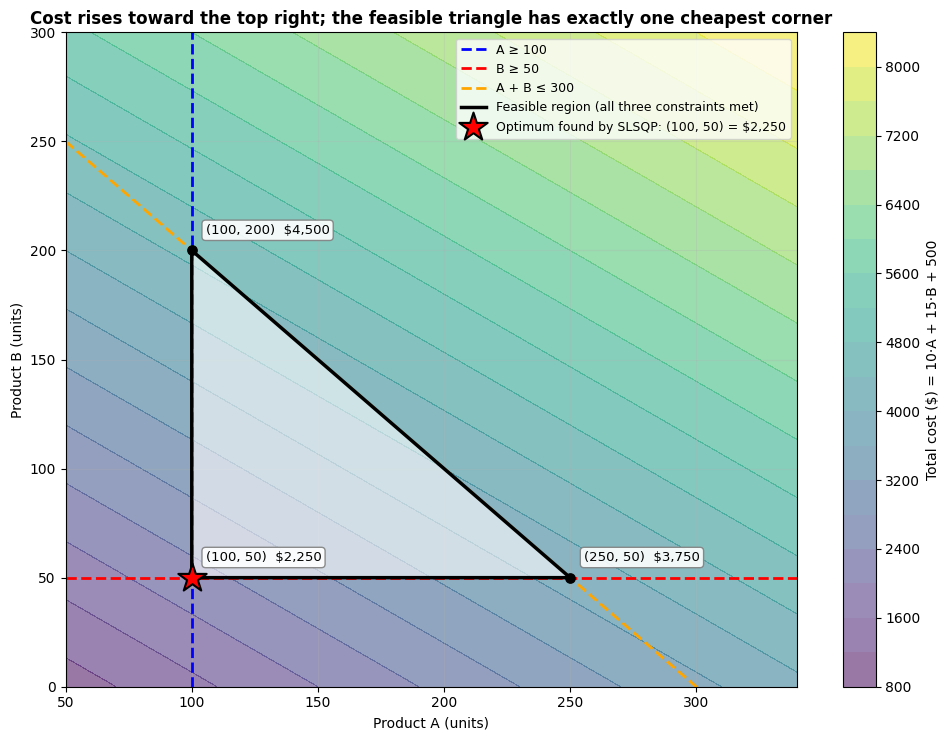


🔎 Read the picture: cost increases with BOTH A and B, so the cheapest point of any
   region is its bottom-left corner. Here that corner is (100, 50) — where the
   'A ≥ 100' and 'B ≥ 50' lines cross — and the three corner labels confirm it:
   $2,250 there against $3,750 and $4,500 at the other two.
   The 'A + B ≤ 300' cap never binds: it cuts off the expensive top-right corner,
   which we had no reason to want. A constraint that does not bind still has to be
   checked — you only learn it was slack after you solve the problem.


In [11]:
# Real-World Application: Production Cost Optimization
# BEFORE: Simple functions, but not real-world problems
# AFTER: Solve real-world problem - minimize production costs!

from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("✅ AFTER: Real-World Optimization Problem")
print("=" * 70)
print()

print("📊 REAL-LIFE EXAMPLE: Production Cost Optimization")
print("   Problem: A company produces two products (A and B)")
print("   Goal: Minimize production cost while meeting demand")
print()
print("   Constraints:")
print("   • Product A: Need at least 100 units")
print("   • Product B: Need at least 50 units")
print("   • Total production capacity: 300 units")
print()
print("   Costs:")
print("   • Product A: $10 per unit")
print("   • Product B: $15 per unit")
print("   • Setup cost: $500 (if producing any units)")
print()

# Define cost function
def production_cost(x):
    """
    Calculate total production cost.
    
    Parameters:
    - x[0]: Units of Product A
    - x[1]: Units of Product B
    
    Returns: Total cost
    """
    cost_A = 10 * x[0]  # $10 per unit of A
    cost_B = 15 * x[1]  # $15 per unit of B
    setup_cost = 500 if (x[0] > 0 or x[1] > 0) else 0  # Setup cost if producing
    total_cost = cost_A + cost_B + setup_cost
    return total_cost

# Constraints
constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0] - 100},  # A >= 100
    {'type': 'ineq', 'fun': lambda x: x[1] - 50},   # B >= 50
    {'type': 'ineq', 'fun': lambda x: 300 - (x[0] + x[1])}  # A + B <= 300
]

# Initial guess
initial_guess = [100, 50]  # Start with minimum requirements

print("🔍 Solving using optimization...")
print()

# Solve using optimization
result = minimize(production_cost, initial_guess, method='SLSQP', constraints=constraints)

# Get optimal solution
optimal_A = result.x[0]
optimal_B = result.x[1]
optimal_cost = result.fun

print("✅ OPTIMAL SOLUTION:")
print(f"   Product A: {optimal_A:.0f} units")
print(f"   Product B: {optimal_B:.0f} units")
print(f"   Total Cost: ${optimal_cost:,.2f}")
print()

# Breakdown of costs
cost_A = 10 * optimal_A
cost_B = 15 * optimal_B
setup = 500

print("📊 Cost Breakdown:")
print(f"   Product A cost: ${cost_A:,.2f} ({optimal_A:.0f} units × $10)")
print(f"   Product B cost: ${cost_B:,.2f} ({optimal_B:.0f} units × $15)")
print(f"   Setup cost: ${setup:,.2f}")
print(f"   Total: ${optimal_cost:,.2f}")
print()

# Verify constraints
print("✅ Constraints Check:")
print(f"   Product A >= 100: {optimal_A:.0f} >= 100 ✓")
print(f"   Product B >= 50: {optimal_B:.0f} >= 50 ✓")
print(f"   Total <= 300: {optimal_A + optimal_B:.0f} <= 300 ✓")
print()

print("🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Manufacturing: Minimize production costs")
print("   • Logistics: Minimize shipping costs")
print("   • Finance: Optimize portfolio allocation")
print("   • Engineering: Optimize design parameters")
print()
print("📊 BEFORE vs AFTER:")
print("   BEFORE: 'I think 150 of A and 100 of B is good' (guess)")
print(f"   AFTER: 'Optimal is {optimal_A:.0f} of A and {optimal_B:.0f} of B' (data-driven!)")

# Visualize the FEASIBLE REGION, not only the cost surface.
# WHY: the answer is a CORNER of the triangle the three constraints carve out. Draw the
# cost window WIDER than the feasible set, otherwise "A >= 100" and "B >= 50" sit on the
# plot edges where they look like decoration instead of the binding constraints they are.
fig, ax = plt.subplots(figsize=(10, 7.5))

A_range = np.linspace(50, 340, 160)
B_range = np.linspace(0, 300, 160)
A_grid, B_grid = np.meshgrid(A_range, B_range)
costs = 10 * A_grid + 15 * B_grid + 500      # same formula as production_cost() above

contour = ax.contourf(A_grid, B_grid, costs, levels=20, cmap='viridis', alpha=0.55)
plt.colorbar(contour, ax=ax, label='Total cost ($) = 10·A + 15·B + 500')

# Each constraint boundary drawn where it ACTUALLY lies
ax.axvline(x=100, color='blue', linestyle='--', linewidth=2, label='A ≥ 100')
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='B ≥ 50')
cap = np.array([50.0, 340.0])
ax.plot(cap, 300 - cap, color='orange', linestyle='--', linewidth=2, label='A + B ≤ 300')

# The feasible set: the triangle with corners (100,50), (250,50), (100,200)
feasible = np.array([[100.0, 50.0], [250.0, 50.0], [100.0, 200.0]])
ax.fill(feasible[:, 0], feasible[:, 1], color='white', alpha=0.6, zorder=2)
ax.plot(np.append(feasible[:, 0], feasible[0, 0]),
        np.append(feasible[:, 1], feasible[0, 1]),
        color='black', linewidth=2.5, zorder=3,
        label='Feasible region (all three constraints met)')

# Label each corner with its own cost - the cheapest corner is the answer
for a, b in feasible:
    ax.scatter([a], [b], color='black', s=45, zorder=6)
    ax.annotate(f'({a:.0f}, {b:.0f})  ${production_cost([a, b]):,.0f}',
                xy=(a, b), xytext=(10, 12), textcoords='offset points', fontsize=9.5, zorder=7,
                bbox=dict(boxstyle='round,pad=0.28', fc='white', ec='grey', alpha=0.9))

ax.scatter([optimal_A], [optimal_B], color='red', s=460, marker='*', zorder=8,
           edgecolors='black', linewidths=1.5,
           label=f'Optimum found by SLSQP: ({optimal_A:.0f}, {optimal_B:.0f}) = ${optimal_cost:,.0f}')

ax.set_xlim(50, 340); ax.set_ylim(0, 300)
ax.set_xlabel('Product A (units)')
ax.set_ylabel('Product B (units)')
ax.set_title('Cost rises toward the top right; the feasible triangle has exactly one cheapest corner',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("\n🔎 Read the picture: cost increases with BOTH A and B, so the cheapest point of any")
print("   region is its bottom-left corner. Here that corner is (100, 50) — where the")
print("   'A ≥ 100' and 'B ≥ 50' lines cross — and the three corner labels confirm it:")
print("   $2,250 there against $3,750 and $4,500 at the other two.")
print("   The 'A + B ≤ 300' cap never binds: it cuts off the expensive top-right corner,")
print("   which we had no reason to want. A constraint that does not bind still has to be")
print("   checked — you only learn it was slack after you solve the problem.")


## 💬 Discuss

All three are answerable from tables printed above, and none has a settled answer.

1. **Part 7's comparison table shows all four methods solving f(x) = x²** — every final cost ≤ 0.000125, hill climbing fastest at 0.0003 s, the genetic algorithm slowest at 0.0167 s. A colleague reads that table and concludes: *"hill climbing is the best optimizer here; genetic algorithms are a waste of compute."* What is wrong with that inference, and which single cell **in this same notebook** refutes it? Then design the fair benchmark you would actually want — what functions, how many runs, what reported statistic?
2. **In Part 4, simulated annealing returned x = 2.1972 with f = −1.9610.** Is that the global minimum? The algorithm cannot tell you: it has no certificate, only a cooled-down best-so-far. Would you sign off a production schedule generated by a method that cannot prove its answer is best? If not, what would you require instead — a mathematical bound, agreement between two different methods, twenty reruns with different seeds? Price each option in engineer-hours.
3. **Both the annealing and genetic-algorithm cells fix `seed = 42`.** That makes this notebook reproducible, and it also makes every reported number a *single draw* from a distribution. Rerun with twenty seeds and you get twenty answers. Which one do you put in the client report — the best, the median, or the worst? What does each choice hide, and which would you want if you were the client?

---


## ⚠️ Where this breaks

Every claim below is visible in this notebook's own printed output.

- **"Converged" does not mean "optimal".** Gradient descent on f(x) = (x−2)² + 2·sin(5x) from x = 5.0 printed `✅ Converged after 22 iterations!` and stopped at x = 4.6029, f = 5.0674. That is a real local minimum: the slope there genuinely is zero. It is also nowhere near the best answer. A gradient method reports success whenever the gradient vanishes, and cannot distinguish a valley from *the* valley.
- **Simulated annealing escapes local minima and proves nothing.** Its answer, x = 2.1972 with f = −1.9610, is close to the global optimum — but the algorithm has no way to say so. Kirkpatrick's convergence guarantee is asymptotic, requiring an infinitely slow cooling schedule; every real run, including the one above with `cooling = 0.95`, is an approximation of a limit nobody can afford.
- **A stochastic method returns a distribution, not a number.** The `np.random.seed(42)` in Part 4 buys reproducibility and hides variance. Report a metaheuristic's result as "median of 20 runs, with the spread", never as one number.
- **The Part 7 comparison is a sanity check, not a benchmark.** It ranks four methods on a convex bowl whose minimum everybody already knows — a problem on which they cannot help but agree. Its own output says so ("all four methods solved this convex function"). Comparing optimizers fairly is genuinely hard; reference 4 (Schmidt, Schneider & Hennig, *Descending through a Crowded Valley*) is an entire paper about how easily optimizer comparisons mislead.
- **The knobs matter as much as the method.** Initial temperature 50, cooling rate 0.95, population 50, mutation 10%, learning rate 0.1 — every one of those was chosen, and every one changes the answer. Tuning them is itself an optimization problem, and hours spent there are hours not spent on the model that actually faces the client.
- **None of Parts 2–5 handles constraints.** Real problems come with "at least 100 units of product A" and "no more than 40 staff hours". That is exactly why Part 8 switches to `scipy.optimize.minimize` with an explicit constraint list rather than reusing the classes you built.
- **The cheaper alternative — and it is usually the right one.** If your problem is smooth and convex, a proper convex solver (or the closed-form solution) beats every heuristic here *and* certifies that the answer is optimal. If it is linear with linear constraints, use a linear-programming solver: decades of engineering, plus a proof. Metaheuristics are the tool for when you have no gradient, no convexity and no exploitable structure. Reach for them **last**, not first — and when you do, expect to defend the answer with reruns rather than with a proof.

---


## Summary: Problem → Solution Realization

### ❌ THE PROBLEM:
1. Need to find optimal solution (min/max)
2. Without optimization: Random search (slow) or grid search (too slow)
3. This leads to inefficient or suboptimal solutions

### ✅ THE SOLUTION:
1. **Gradient Descent**: Follow gradient downhill to minimum
2. **Genetic Algorithms**: Evolve solutions
3. **Simulated Annealing**: Escape local minima

### 🔗 HOW THE SOLUTION SOLVES THE PROBLEM:
- ✅ Instead of random search → Systematic search
- ✅ Instead of slow → Fast convergence
- ✅ Instead of guessing → Mathematical methods that efficiently find optimum

### 📊 BEFORE vs AFTER:
- **BEFORE**: Problem → Random tries → Slow, might miss optimum
- **AFTER**: Problem → Optimization algorithm → Fast, finds optimum!

### 🔗 How This Connects to Other Notebooks:

**What you learned here builds on and leads to:**
- **Notebook 1: Search Algorithms** - Search algorithms are optimization problems! Finding the shortest path is optimizing (minimizing path length). A* algorithm uses optimization concepts (minimizing f = g + h).

- **Notebook 3: Learning under Uncertainty** - Decision-making under uncertainty uses optimization (maximizing expected utility). Both involve finding the best solution among alternatives.

- **Notebook 5: AI Learning Models** - Machine learning IS optimization! Training a model means finding optimal parameters that minimize loss. Gradient descent (from this notebook) is the core of how neural networks learn!

**Why this order?**
1. **After Search**: Search algorithms introduce optimization concepts (finding best path)
2. **After Uncertainty**: Decision-making uses optimization (maximizing expected value)
3. **Before ML Models**: ML training is optimization - understanding optimization is essential

### Key Takeaways:
1. **Optimization finds best solutions**: Mathematical methods to find minimum/maximum efficiently
2. **Different algorithms for different problems**: Gradient descent for smooth functions, genetic algorithms for complex problems
3. **Core of machine learning**: Training ML models is an optimization problem - finding parameters that minimize loss
4. **Essential skill**: Optimization is used throughout AI, from search to learning to decision-making

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

Gradient descent itself is untouched — every trained model in this diploma, and every frontier model outside it, is fitted by the loop you wrote in Part 2. What moved is the *objective*. Since 2023 the dominant optimization problem in AI has been fitting a language model to preferences or to a checkable reward, and two methods define current practice: Direct Preference Optimization, which removes the separate reward model and optimizes preference pairs with an ordinary classification-style loss (Rafailov *et al.*, 2023), and GRPO, which estimates how good a sampled answer was by comparing it with a group of other sampled answers instead of training a value network (Shao *et al.*, 2024). Both are still "measure the slope, step downhill" — seeing that clearly is the payoff of this lesson, not a footnote to it. Meanwhile the metaheuristics are alive exactly where gradients do not exist: timetables, layouts, routing and scheduling are still solved with annealing, evolutionary search or a dedicated solver, which is why they are taught beside the gradient rather than instead of it.

**Read:** Rafailov *et al.* (2023), <https://arxiv.org/abs/2305.18290> · Shao *et al.* (2024), <https://arxiv.org/abs/2402.03300> (references 5-6 below).

---

## 📚 References

1. Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). *Optimization by Simulated Annealing*. Science 220(4598), 671-680.
2. Holland, J. H. (1975). *Adaptation in Natural and Artificial Systems*. University of Michigan Press. (the foundation of genetic algorithms)
3. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR 2015. <https://arxiv.org/abs/1412.6980> (the gradient-descent variant most used in modern ML)
4. Schmidt, R. M., Schneider, F., & Hennig, P. (2021). *Descending through a Crowded Valley - Benchmarking Deep Learning Optimizers*. arXiv preprint. <https://arxiv.org/abs/2007.01547>
5. Rafailov, R., Sharma, A., Mitchell, E., Ermon, S., Manning, C. D., & Finn, C. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*. arXiv preprint. <https://arxiv.org/abs/2305.18290> (the same gradient descent, with human preferences in place of a squared error)
6. Shao, Z., Wang, P., Zhu, Q., Xu, R., Song, J., Bi, X., Zhang, H., Zhang, M., Li, Y. K., Wu, Y., & Guo, D. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models*. arXiv preprint. <https://arxiv.org/abs/2402.03300> (introduces GRPO, the policy-optimization method behind most 2025-26 reasoning training)
7. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Chapter 4 (Search in Complex Environments: hill climbing, simulated annealing, genetic algorithms). Pearson. <https://aima.cs.berkeley.edu/>